## Store Item Demand Forecasting Challenge (kaggle)



### 1. Problem Identification and Background

In financial management, inventory turnover is a critical factor that can lead to bankruptcy if not properly measured,due to storage high costs, waste and opportunity costs resulting from poor inventory management. The cost of inventory is calculated as follows: Inventory = Cost of capital + Cost of inventory risk + Handling and maintenance costs

**The Business Case: Lowe’s Mexico**

Lowe’s Mexico fell victim to poor inventory management combined with slow growth. Failure to correctly identify which items should be rotated and which should not, coupled with logistical challenges in keeping shelves stocked, caused the operation to become unprofitable.

**Why is inventory management important?**

  If you have a small warehouse (low storage cost): 
  - You have to restock product more often (transportation and shipping costs).
  - Risking running out of stock (low sales).
  - You can't offer discounts on products that are not selling (opportunity cost).

By using machine learning, product demand can be predicted to achieve optimal inventory turnover and replenishment based on seasonal trends and previous annual sales.

## Data Extraction and Preprocessing

Data Description:
- The data consists of daily sales data for 10 different stores and 50 different items, of the kaggle competition "Store Item Demand Forecasting Challenge". The data spans from January 1, 2013, to December 31, 2017. The dataset includes the following columns:
  - date: The date of the sales record.
  - store: The store number (1 to 10).
  - item: The item number (1 to 50).
  - sales: The number of items sold on that date at that store.

In [288]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.dates as mdates
import seaborn as sns

from pmdarima import auto_arima
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
folder = "proyects/"

In [34]:
df_train = pd.read_csv(folder + "Demand_Forecasting_train.csv", parse_dates=["date"])
df_val = pd.read_csv(folder + "Demand_Forecasting_test.csv", parse_dates=["date"])
df_train['date'] = pd.to_datetime(df_train['date'])
df_val['date'] = pd.to_datetime(df_val['date'])
df_train = df_train.set_index('date')
df_val = df_val.set_index('date')
print(df_val.head())
print(df_train.head())


            id  store  item
date                       
2018-01-01   0      1     1
2018-01-02   1      1     1
2018-01-03   2      1     1
2018-01-04   3      1     1
2018-01-05   4      1     1
            store  item  sales
date                          
2013-01-01      1     1     13
2013-01-02      1     1     11
2013-01-03      1     1     14
2013-01-04      1     1     13
2013-01-05      1     1     10


In [35]:
#let's drop the id column from the validation dataset
df_val = df_val.drop(columns=['id'])

# checking empty, null and duplicated values
print("Empty values in train:", df_train.isnull().sum())
print("Empty values in validation:", df_val.isnull().sum()) 
print("Duplicated values in train:", df_train.duplicated().sum())
print("Duplicated values in validation:", df_val.duplicated().sum())
print("Data types in train:\n", df_train.dtypes)
print("Data types in validation:\n", df_val.dtypes)

Empty values in train: store    0
item     0
sales    0
dtype: int64
Empty values in validation: store    0
item     0
dtype: int64
Duplicated values in train: 872564
Duplicated values in validation: 44500
Data types in train:
 store    int64
item     int64
sales    int64
dtype: object
Data types in validation:
 store    int64
item     int64
dtype: object


In [25]:
df_train.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


## Data Visualization and Exploratory Data Analysis

##### Let's see first how many stores we have and how many items we have in the dataset

In [78]:
print(f"Number of unique stores: {df_train['store'].nunique()}")
print(f"Number of unique items: {df_train['item'].nunique()}")

Number of unique stores: 10
Number of unique items: 50


<Figure size 1500x600 with 0 Axes>

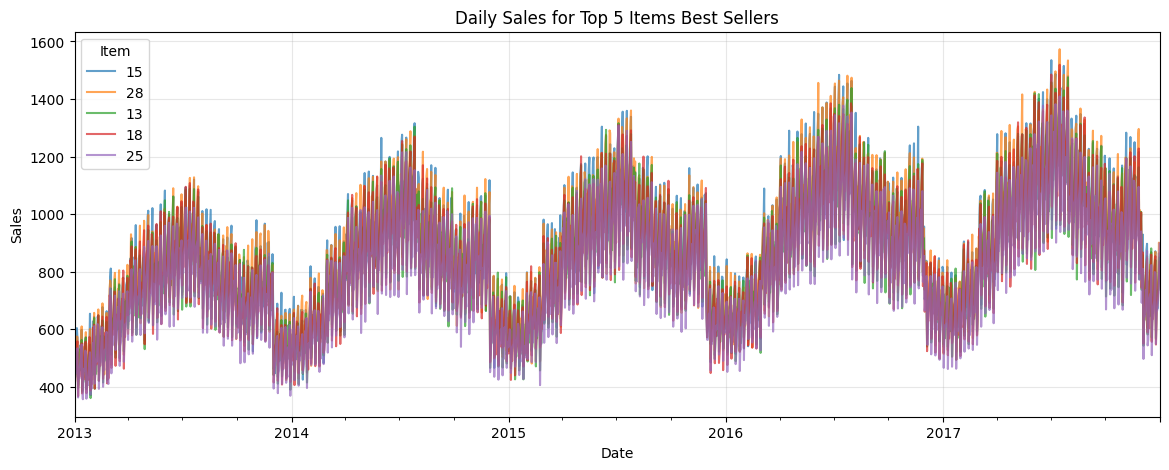

In [83]:
# Plot average daily sales per item (first few items for clarity)
def visualisation_items(df):
    data = df.groupby(['date', 'item'])['sales'].sum().unstack()

    top_items = data.sum().sort_values(ascending=False).head(5).index
    data = data[top_items]
    
    plt.figure(figsize=(15, 6))
    data.iloc[:, :5].plot(title='Daily Sales for Top 5 Items Best Sellers', alpha=0.7)
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.legend(title='Item')
    plt.grid(True)
    plt.show()
visualisation_items(df_train)
#We can see the item 15 is the best seller

<Figure size 1500x600 with 0 Axes>

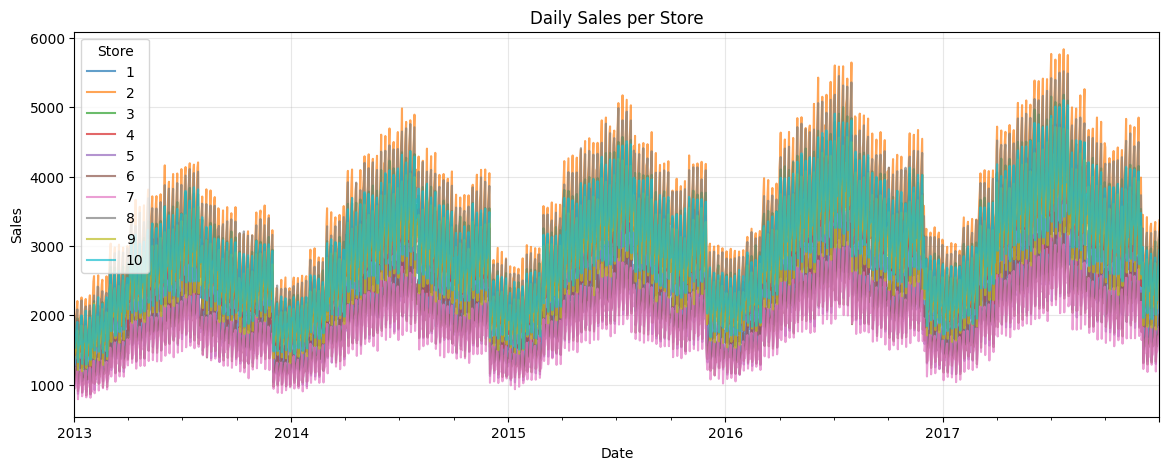

In [131]:
def visualization_stores(df, date_range=None, title='Daily Sales per Store'):
    data = df.copy()
    data.index = pd.to_datetime(data.index)
    data = data.groupby([data.index, 'store'])['sales'].sum().unstack()
    if date_range is not None:
        start, end = pd.to_datetime(date_range[0]), pd.to_datetime(date_range[1])
        data = data.loc[(data.index >= start) & (data.index <= end)]
    plt.figure(figsize=(15, 6))
    data.plot(title=title, alpha=0.7)
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.legend(title='Store')
    plt.grid(True)
    plt.show()

#visualization(df_train, date_range=('2014-01-01', '2014-12-31'))
visualization_stores(df_train)


##### Let's take a look closer by year, and by month

<Figure size 1500x600 with 0 Axes>

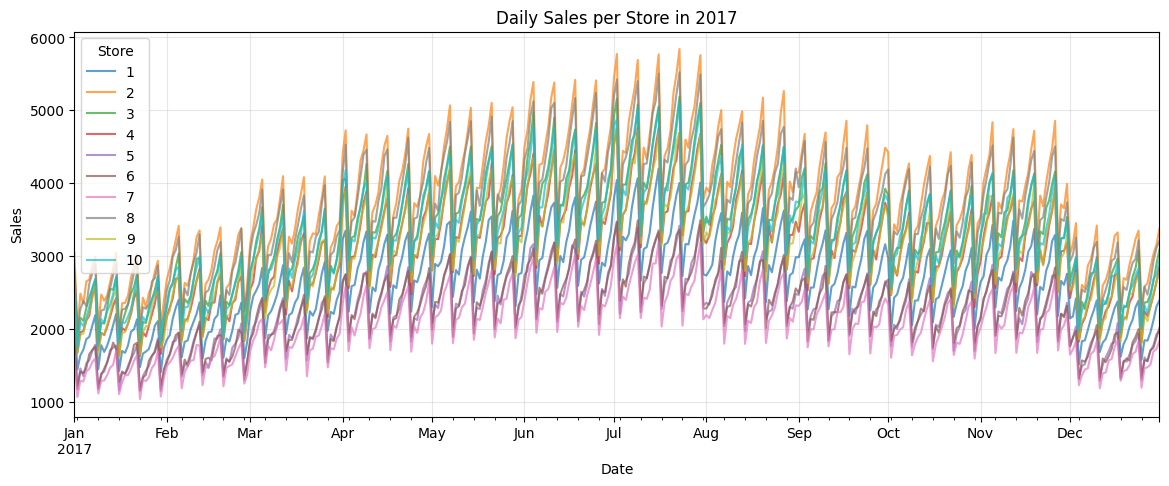

<Figure size 1500x600 with 0 Axes>

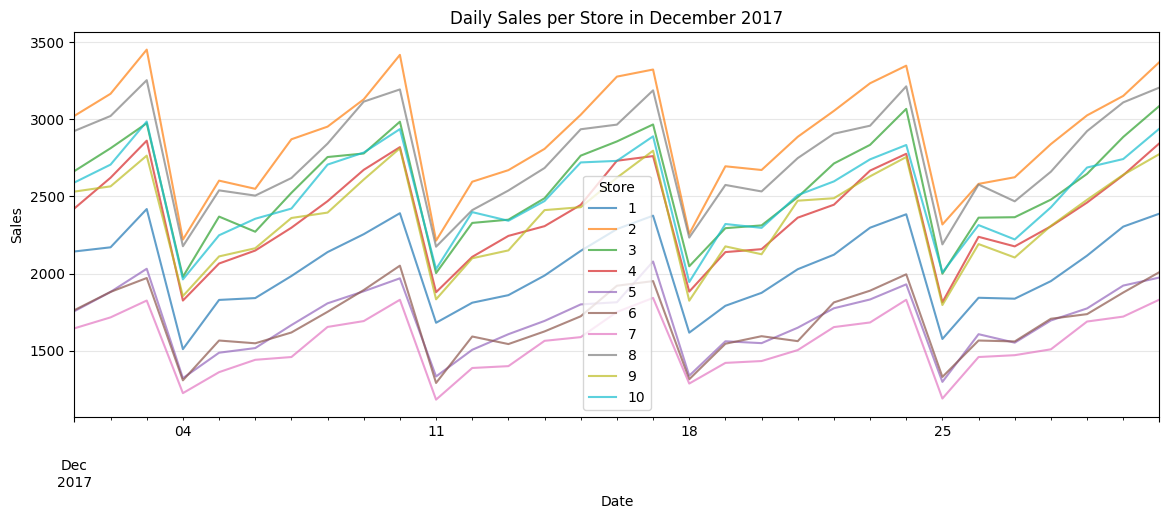

<Figure size 1500x600 with 0 Axes>

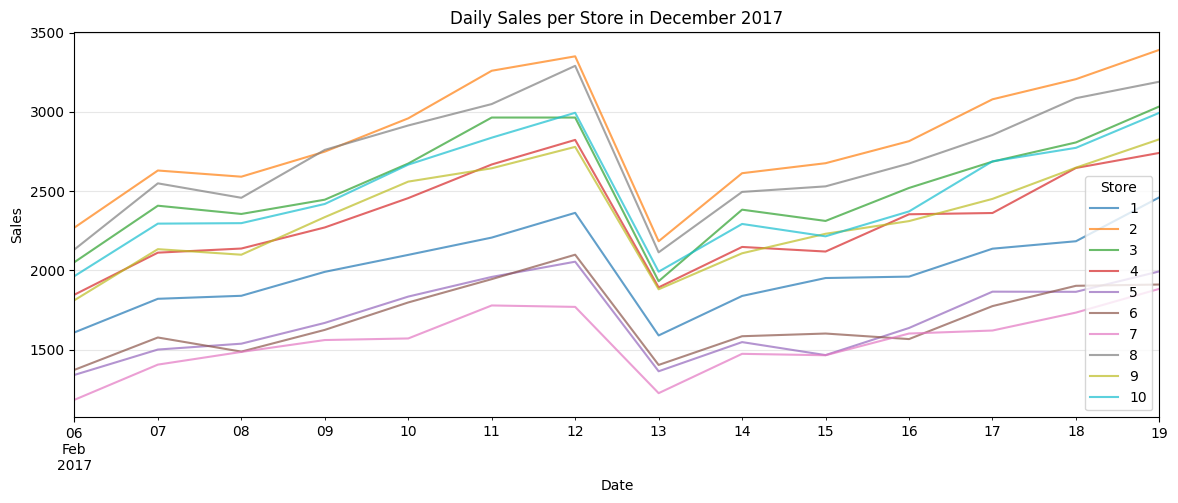

In [168]:
visualization_stores(df_train, date_range=('2017-01-01', '2017-12-31'), title='Daily Sales per Store in 2017')
visualization_stores(df_train, date_range=('2017-12-01', '2017-12-31'), title='Daily Sales per Store in December 2017')
visualization_stores(df_train, date_range=('2017-02-06', '2017-02-19'), title='Daily Sales per Store in December 2017')

We can see a seasonality per year with peaks in Jul-Aug, and a seasonality per week with serials peaks on the weekends, and a drop on the first day of the week, Monday. Let's verfiy in another way the seasonality per week, by plotting the average sales per day of the week.

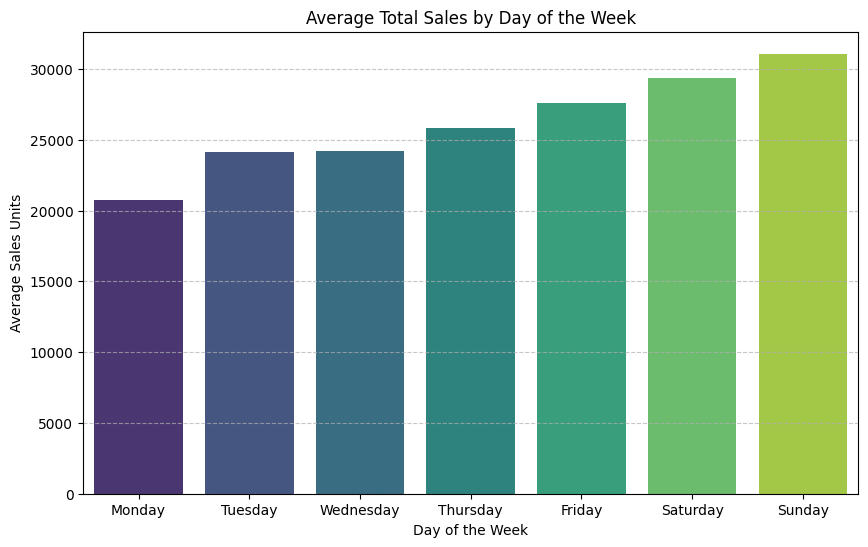

day_of_week
Monday       20714.819231
Tuesday      24112.954023
Wednesday    24184.252874
Thursday     25861.609195
Friday       27578.624521
Saturday     29331.348659
Sunday       31071.666667
Name: total_sales, dtype: float64


In [ ]:
data = df_train.copy()
data.index = pd.to_datetime(data.index)
data = data.groupby([data.index, 'store'])['sales'].sum().unstack()
total_daily_sales = data.sum(axis=1).to_frame(name='total_sales')
total_daily_sales['day_of_week'] = total_daily_sales.index.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_pattern = total_daily_sales.groupby('day_of_week')['total_sales'].mean().reindex(days_order)
plt.figure(figsize=(10, 6))
sns.barplot(x=weekly_pattern.index, y=weekly_pattern.values, palette='viridis')
plt.title('Average Total Sales by Day of the Week')
plt.ylabel('Average Sales Units')
plt.xlabel('Day of the Week')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(weekly_pattern)

##### We will take the store 2 to do the analysis, because is the store with more sales of all the products, and the best seller product, the product 15.

In [ ]:
# the store that have more sells of all the products
store_sales = df_train.groupby('store')['sales'].sum().sort_values(ascending=False)
print("Total sales per store:\n", store_sales)
item_sales = df_train.groupby('item')['sales'].sum().sort_values(ascending=False)
print("Total sales per item:\n", item_sales[:10])
# We can see the store 2 is the store with more sales of all products, and the product 15 is the best seller.

Total sales per store:
 store
2     6120128
8     5856169
3     5435144
10    5360158
9     5025976
4     5012639
1     4315603
5     3631016
6     3627670
7     3320009
Name: sales, dtype: int64
Total sales per item:
 item
15    1607442
28    1604713
13    1539621
18    1538876
25    1473334
45    1471467
38    1470330
22    1469971
36    1406548
8     1405108
Name: sales, dtype: int64


#### Daily DataSet

Date range : 2013-01-01 → 2017-12-31
Total days: 1826
Total weeks    : 261
Total months   : 60


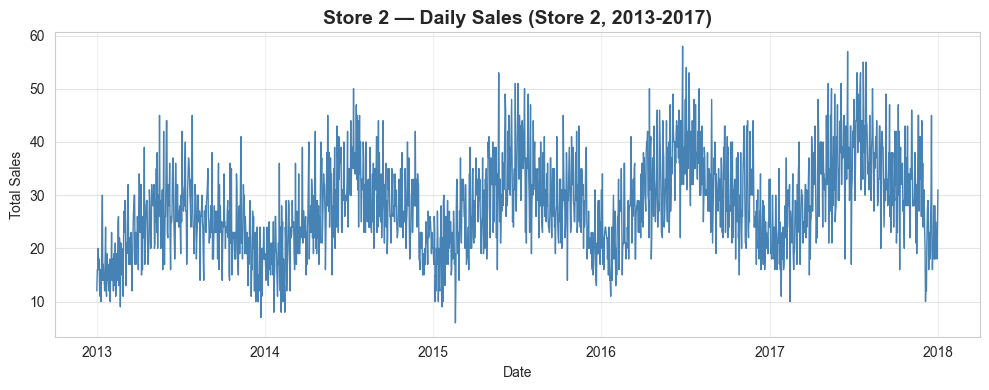

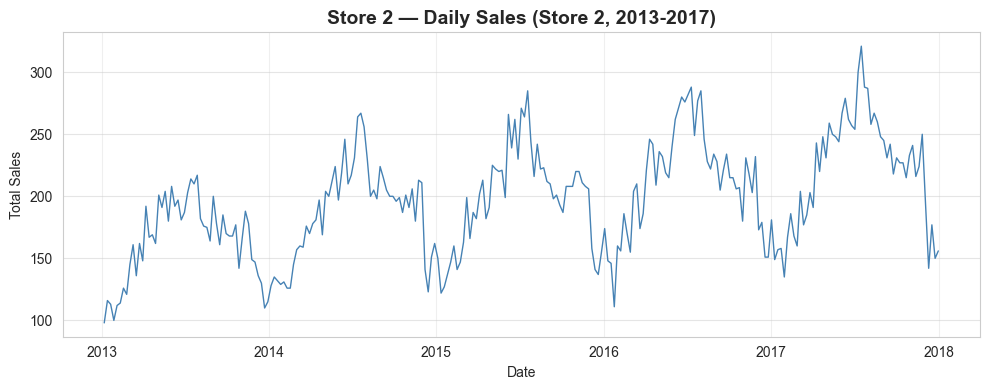

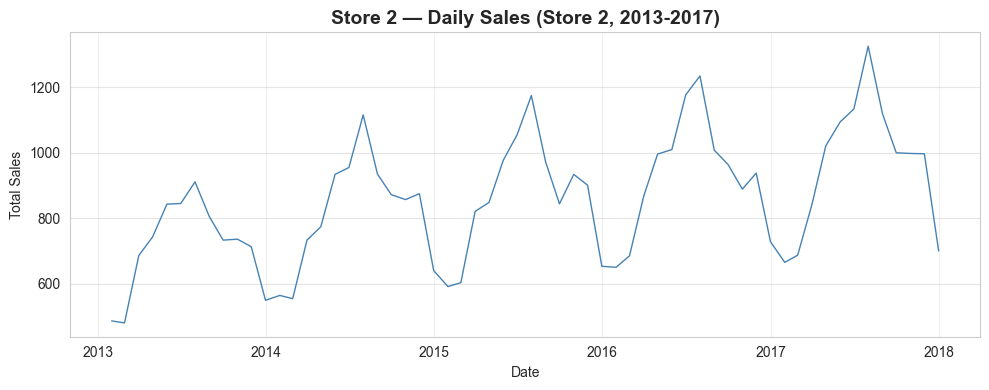

In [306]:
# Keep item 1 only, of the store 2
item1_store_2 = df_train[(df_train['store'] == 2) & (df_train['item'] == 1)].copy()
item1_store_2 = item1_store_2.groupby('date')['sales'].sum()

item1_store_2_weekly = item1_store_2.resample('W').sum()

item1_store_2_monthly = item1_store_2.resample('M').sum()

print(f"Date range : {item1_store_2.index[0].date()} → {item1_store_2.index[-1].date()}")
print(f"Total days: {len(item1_store_2)}")
print(f"Total weeks    : {len(item1_store_2_weekly)}")
print(f"Total months   : {len(item1_store_2_monthly)}")



def plot_sales(data, title='Store 2 — Daily Sales (Store 2, 2013-2017)'):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(data.index, data.values, color='steelblue', linewidth=1.0, markersize=3)
    ax.set_title('Store 2 — Daily Sales (Store 2, 2013-2017)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Total Sales')
    ax.grid(axis='y', alpha=0.5)
    plt.tight_layout()
    plt.show()
plot_sales(item1_store_2)
plot_sales(item1_store_2_weekly, title='Store 2 — Weekly Sales (Store 2, 2013-2017)')
plot_sales(item1_store_2_monthly, title='Store 2 — Monthly Sales (Store 2, 2013-2017)')



In [308]:
train_ts = item1_store_2[item1_store_2.index.year < 2017]
test_ts  = item1_store_2[item1_store_2.index.year == 2017]
train_ts.index = pd.to_datetime(train_ts.index)
test_ts.index = pd.to_datetime(test_ts.index)
train_weekly = train_ts.resample('W').sum()
test_weekly = test_ts.resample('W').sum()
train_monthly = train_ts.resample('M').sum()
test_monthly = test_ts.resample('M').sum()

print(f"Train (2013-2016): {len(train_ts.index.to_period('M').unique())} months  |  Test (2017): {len(test_ts.index.to_period('M').unique())} months")

Train (2013-2016): 48 months  |  Test (2017): 12 months


#### Baseline model: Linear Regression

MAE: 7.61
RMSE: 9.27
MAE: 38.85
RMSE: 51.58
MAE: 156.58
RMSE: 198.51


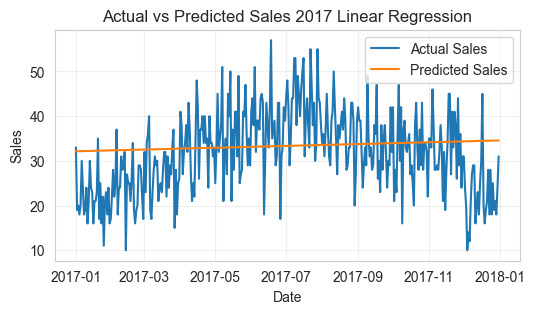

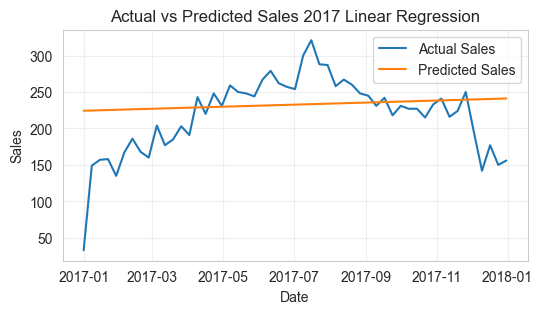

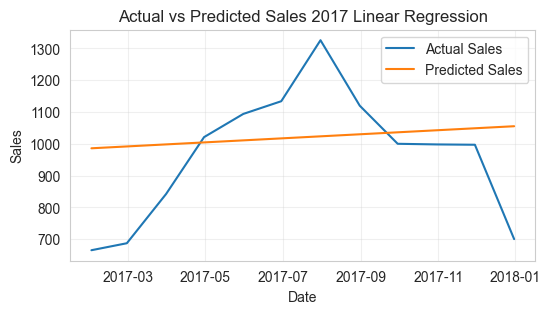

In [ ]:
def baseline_model(train_ts):
    ts = train_ts.reset_index()
    ts['date'] = pd.to_datetime(ts['date'])

    ts['date_num'] = ts['date'].astype('int64') // 10**9 
    X = ts[['date_num']]
    y = ts['sales']

    model = LinearRegression()
    model.fit(X, y)
    return model

def evaluate_model(test_ts, model):
    tt = test_ts.reset_index()
    tt['date'] = pd.to_datetime(tt['date'])
    tt['date_num'] = tt['date'].astype('int64') // 10**9
    X_test = tt[['date_num']]
    y_true = tt['sales']
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")



def visualize_linear_forecast(test_ts, model):
    tt = test_ts.reset_index()
    tt['date'] = pd.to_datetime(tt['date'])
    tt['date_num'] = tt['date'].astype('int64') // 10**9
    X_test = tt[['date_num']]
    tt['pred_sales'] = model.predict(X_test)
    
    plt.figure(figsize=(6, 3))
    plt.plot(tt['date'], tt['sales'], label='Actual Sales')
    plt.plot(tt['date'], tt['pred_sales'], label='Predicted Sales')
    plt.title('Actual vs Predicted Sales 2017 Linear Regression')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.legend()
    plt.show()

model = baseline_model(train_ts)
model_weekly = baseline_model(train_weekly)
model_monthly = baseline_model(train_monthly)

evaluate_model(test_ts, model)
evaluate_model(test_weekly, model_weekly)
evaluate_model(test_monthly, model_monthly)

visualize_linear_forecast(test_ts, model)
visualize_linear_forecast(test_weekly, model_weekly)
visualize_linear_forecast(test_monthly, model_monthly)


#### Random Forest Regressor 


##### Baseline

In [311]:
ts = train_ts.reset_index()
ts['date'] = pd.to_datetime(ts['date'])
ts['date_num'] = ts['date'].astype('int64') // 10**9 
X = ts[['date_num']]
y = ts['sales']

model = RandomForestRegressor(n_estimators=100)
model.fit(X, y)

tt = test_ts.reset_index()
tt['date'] = pd.to_datetime(tt['date'])
tt['date_num'] = tt['date'].astype('int64') // 10**9
X_test = tt[['date_num']]
y_true = tt['sales']
y_pred = model.predict(X_test)
    
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 8.76
RMSE: 10.80


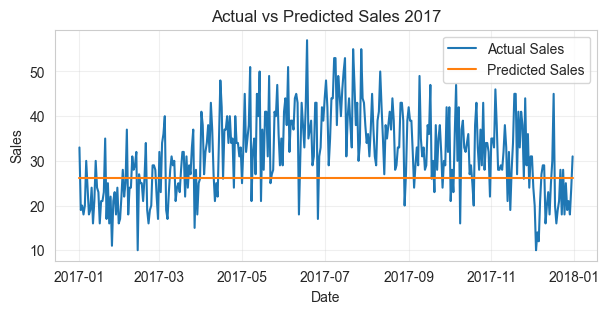

In [313]:
tt['pred_sales'] = model.predict(X_test)
plt.figure(figsize=(7, 3))
plt.plot(tt['date'], tt['sales'], label='Actual Sales')
plt.plot(tt['date'], tt['pred_sales'], label='Predicted Sales')
plt.title('Actual vs Predicted Sales 2017')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

##### Random Forest regressor treats every row as an independent observation. If you feed it a raw date, it won't know that January 2nd follows January 1st. To make this work, you have to transform your time series into a supervised learning problem through **feature engineering**.

In [316]:
def train_random_forest(train_ts):
    data = train_ts.to_frame()
    data['day_of_week'] = data.index.dayofweek
    data['lag_1'] = data['sales'].shift(1)  # Yesterday's sales
    data['lag_2'] = data['sales'].shift(2)  # Two days ago
    data.dropna(inplace=True)
    X = data[['day_of_week', 'lag_1', 'lag_2']]
    y = data['sales']
    model = RandomForestRegressor(n_estimators=100)
    model.fit(X, y)
    return model
model_rf = train_random_forest(train_ts)
model_rf_weekly = train_random_forest(train_weekly)
model_rf_monthly = train_random_forest(train_monthly)

MAE: 5.87
RMSE: 7.31


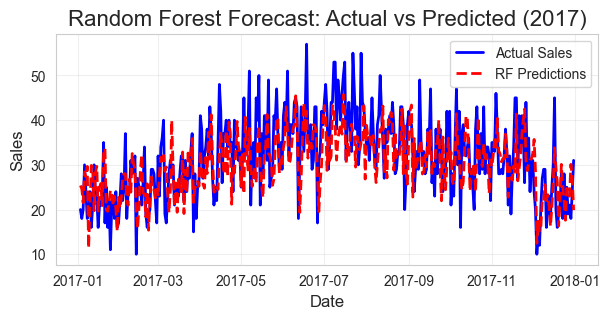

MAE: 18.83
RMSE: 25.92


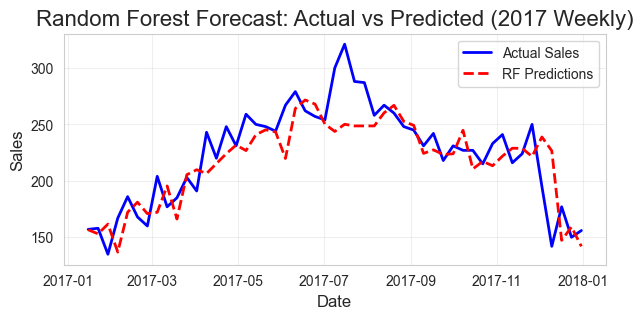

MAE: 129.88
RMSE: 186.82


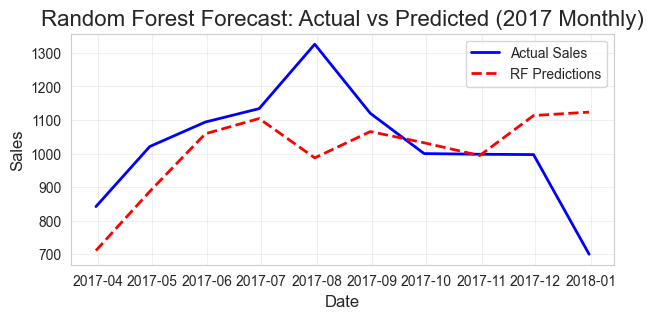

MAE: 4.95
RMSE: 5.98


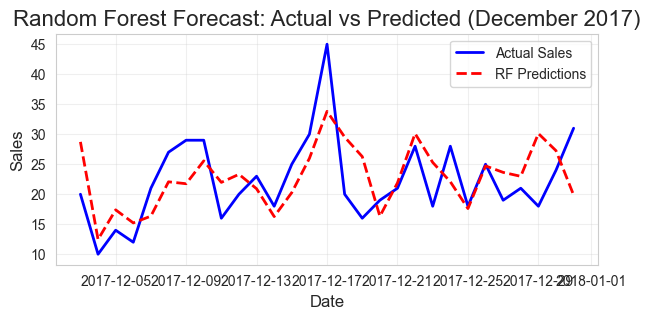

In [318]:
def evaluate_rf(test, model, title='Random Forest Forecast: Actual vs Predicted (2017)'):
    data = test.to_frame()
    data['day_of_week'] = data.index.dayofweek
    data['lag_1'] = data['sales'].shift(1)
    data['lag_2'] = data['sales'].shift(2)
    data.dropna(inplace=True)
    X_test = data[['day_of_week', 'lag_1', 'lag_2']]
    data['pred_sales'] = model.predict(X_test)
    mae = mean_absolute_error(data['sales'], data['pred_sales'])
    rmse = np.sqrt(mean_squared_error(data['sales'], data['pred_sales']))
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    
    plt.figure(figsize=(7, 3))
    plt.plot(data.index, data['sales'], label='Actual Sales', color='blue', linewidth=2)
    plt.plot(data.index, data['pred_sales'], label='RF Predictions', color='red', linestyle='--', linewidth=2)
    plt.title(title, fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Sales', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

evaluate_rf(test_ts, model_rf)
evaluate_rf(test_weekly, model_rf_weekly, title='Random Forest Forecast: Actual vs Predicted (2017 Weekly)')
evaluate_rf(test_monthly, model_rf_monthly, title='Random Forest Forecast: Actual vs Predicted (2017 Monthly)')

filtered = test_ts.loc['2017-12']
evaluate_rf(filtered, model_rf, title='Random Forest Forecast: Actual vs Predicted (December 2017)')

##### Model Sarimax

In [281]:
# Find the best parameters automatically
stepwise_fit = auto_arima(train_ts, start_p=1, start_q=1,
                          max_p=3, max_q=3, m=7, # m=7 for weekly
                          start_P=0, seasonal=True,
                          d=1, D=1, trace=True,
                          error_action='ignore',  
                          suppress_warnings=True, 
                          stepwise=True)

print(stepwise_fit.summary())

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[7]             : AIC=inf, Time=2.40 sec
 ARIMA(0,1,0)(0,1,0)[7]             : AIC=10987.100, Time=0.08 sec
 ARIMA(1,1,0)(1,1,0)[7]             : AIC=10097.421, Time=0.21 sec
 ARIMA(0,1,1)(0,1,1)[7]             : AIC=inf, Time=0.96 sec
 ARIMA(1,1,0)(0,1,0)[7]             : AIC=10565.412, Time=0.10 sec
 ARIMA(1,1,0)(2,1,0)[7]             : AIC=9951.727, Time=0.51 sec
 ARIMA(1,1,0)(2,1,1)[7]             : AIC=inf, Time=3.36 sec
 ARIMA(1,1,0)(1,1,1)[7]             : AIC=inf, Time=1.39 sec
 ARIMA(0,1,0)(2,1,0)[7]             : AIC=10344.656, Time=0.42 sec
 ARIMA(2,1,0)(2,1,0)[7]             : AIC=9801.498, Time=0.67 sec
 ARIMA(2,1,0)(1,1,0)[7]             : AIC=9942.201, Time=0.37 sec
 ARIMA(2,1,0)(2,1,1)[7]             : AIC=inf, Time=4.76 sec
 ARIMA(2,1,0)(1,1,1)[7]             : AIC=inf, Time=2.31 sec
 ARIMA(3,1,0)(2,1,0)[7]             : AIC=9729.695, Time=0.76 sec
 ARIMA(3,1,0)(1,1,0)[7]             : AIC=9882.834, Time=0.

In [ ]:
def train_sarima(data):
    model = SARIMAX(
        data,
        order=(2, 1, 2),# (p, d, q)
        seasonal_order=(2, 1, 0, 7), # (P, D, Q, s)
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    result = model.fit(disp=False)
    print(result.summary())
    return result
result = train_sarima(train_ts)
result_weekly = train_sarima(train_weekly)
result_monthly = train_sarima(train_monthly)


                                     SARIMAX Results                                      
Dep. Variable:                              sales   No. Observations:                 1461
Model:             SARIMAX(2, 1, 2)x(2, 1, [], 7)   Log Likelihood               -4695.544
Date:                            Sun, 12 Apr 2026   AIC                           9405.087
Time:                                    15:31:34   BIC                           9441.980
Sample:                                01-01-2013   HQIC                          9418.861
                                     - 12-31-2016                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8093      0.098      8.288      0.000       0.618       1.001
ar.L2          0.0140      0.036   

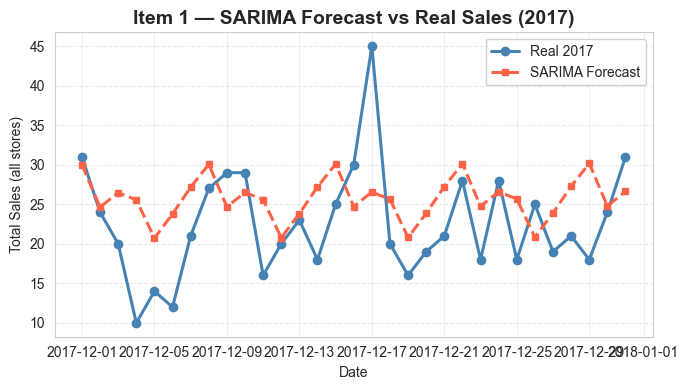

In [ ]:
def visualize_sarima_forecast(model, data):
        forecast = model.get_forecast(steps=len(data))
        pred_mean1 = forecast.predicted_mean
        pred_mean1.index = data.index   # align index
        fig, ax = plt.subplots(figsize=(7, 3))
        start = "2017-12-01"
        end = "2017-12-31"
        data_f = data.loc[start:end]
        pred_mean1_f = pred_mean1.loc[start:end]
        # 2017 real sales
        ax.plot(data_f.index, data_f.values,color='steelblue', linewidth=2.2, marker='o', markersize=6, label='Real 2017')

        # SARIMA prediction
        ax.plot(pred_mean1_f.index, pred_mean1_f.values, color='tomato', linewidth=2.2, linestyle='--', marker='s', markersize=5, label='SARIMA Forecast')

        ax.set_title('Item 1 — SARIMA Forecast vs Real Sales (2017)', fontsize=14, fontweight='bold')
        ax.set_xlabel('Date')
        ax.set_ylabel('Total Sales (all stores)')
        ax.legend(framealpha=0.9)
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.show()

visualize_sarima_forecast(result,test_ts)
visualize_sarima_forecast(result_weekly,test_weekly)
visualize_sarima_forecast(result_monthly,test_monthly)

#### XGBoost Regressor

Raw dates aren't easily understood by most machine learning models (like Random Forest or XGBoost), so we decompose the date into features that represent time cycles , like **Rolling Windows**, the average or standard deviation of the last 7 or 30 days, or **Calendar Features**, extract the day of the week, month, or whether it's a holiday to help the model learn that sales might spike every Saturday or drop every January, in our case **drop every august, and every monday**.

In [294]:
def create_features(df):
    """
    Creates time series features from a datetime index.
    """
    df = df.copy()
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    
    # Lag Features (The manual way)
    # This tells the model what happened 7, 14, and 30 days ago
    df['lag7'] = df['sales'].shift(7)
    df['lag14'] = df['sales'].shift(14)
    df['lag30'] = df['sales'].shift(30)
    
    # Rolling Mean (Smoothing)
    df['rolling_mean_7'] = df['sales'].shift(1).rolling(window=7).mean()
    
    return df


df_xgb = item1_store_2.to_frame(name='sales')
df_xgb_features = create_features(df_xgb).dropna()

train = df_xgb_features[df_xgb_features.index.year < 2017]
test = df_xgb_features[df_xgb_features.index.year == 2017]

def train_xgboost(train, test):
        # Define Features (X) and Target (y)
        FEATURES = ['dayofweek', 'quarter', 'month', 'year', 'dayofyear', 
                'lag7', 'lag14', 'lag30', 'rolling_mean_7']
        TARGET = 'sales'

        X_train = train[FEATURES]
        y_train = train[TARGET]

        X_test = test[FEATURES]
        y_test = test[TARGET]

        # Initialize the model
        reg = xgb.XGBRegressor(n_estimators=1000, 
                        early_stopping_rounds=50,
                        learning_rate=0.01,
                        max_depth=5)

        # Fit the model
        reg.fit(X_train, y_train,
                eval_set=[(X_train, y_train), (X_test, y_test)],
                verbose=100)
        
        return reg

model_xgb = train_xgboost(train, test)

[0]	validation_0-rmse:8.14835	validation_1-rmse:10.07532


[100]	validation_0-rmse:5.62140	validation_1-rmse:7.29072
[200]	validation_0-rmse:4.86129	validation_1-rmse:6.55368
[300]	validation_0-rmse:4.48854	validation_1-rmse:6.33931
[400]	validation_0-rmse:4.23651	validation_1-rmse:6.26039
[450]	validation_0-rmse:4.14065	validation_1-rmse:6.27156


MAE: 4.97
RMSE: 6.26


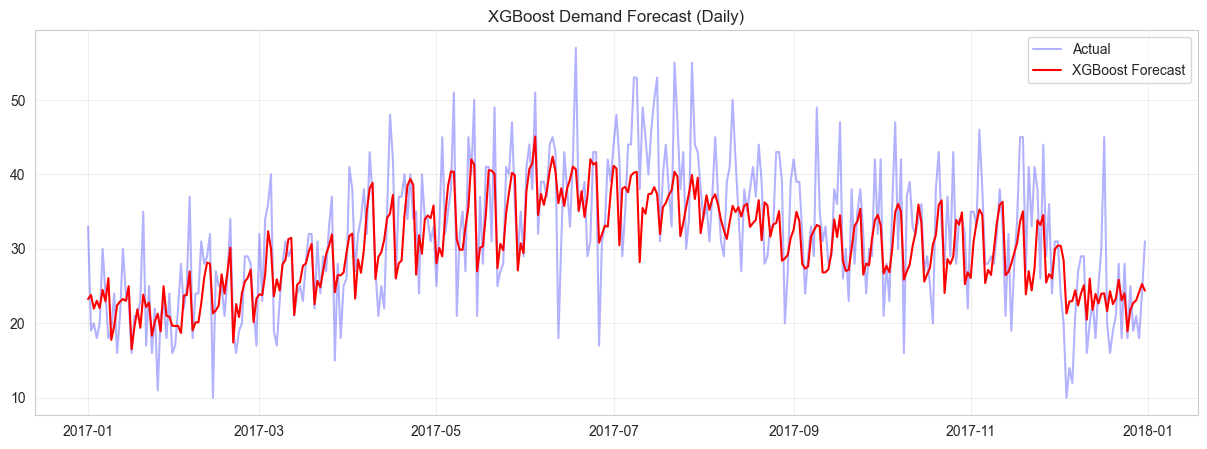

MAE: 5.21
RMSE: 6.57


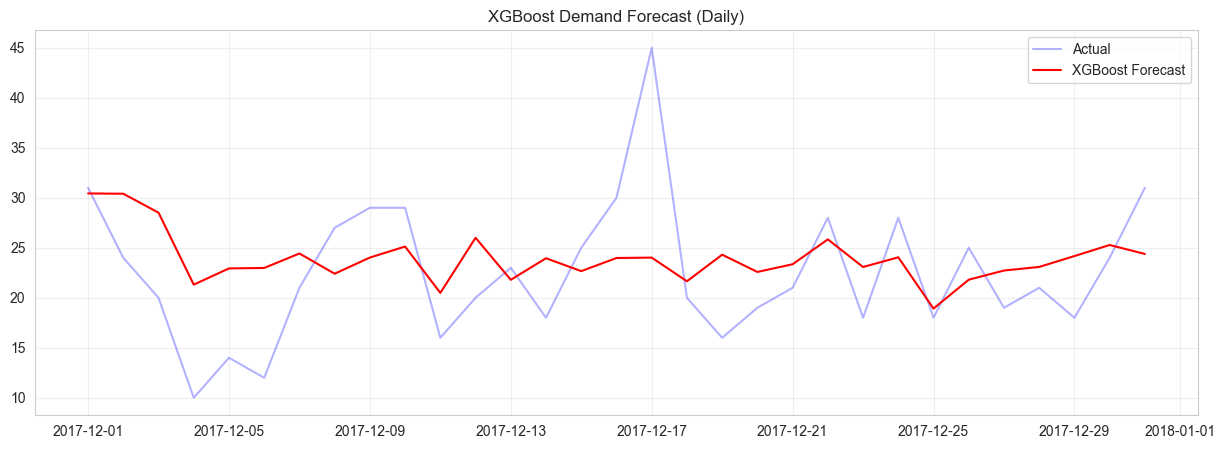

In [297]:
def predict_xgboost(model, test): 
    FEATURES = ['dayofweek', 'quarter', 'month', 'year', 'dayofyear', 
                'lag7', 'lag14', 'lag30', 'rolling_mean_7']
    TARGET = 'sales'

    X_test = test[FEATURES]
    y_test = test[TARGET]
   # Predict
    test['prediction'] = model.predict(X_test)

    # Calculate Metrics
    mae = mean_absolute_error(y_test, test['prediction'])
    rmse = np.sqrt(mean_squared_error(y_test, test['prediction']))

    print(f'MAE: {mae:.2f}')
    print(f'RMSE: {rmse:.2f}')


    plt.figure(figsize=(15, 5))
    plt.plot(test.index, test['sales'], label='Actual', color='blue', alpha=0.3)
    plt.plot(test.index, test['prediction'], label='XGBoost Forecast', color='red')
    plt.title('XGBoost Demand Forecast (Daily)')
    plt.legend()
    plt.show()
  
predict_xgboost(model_xgb, test)
filtered = test.loc['2017-12']
predict_xgboost(model_xgb, filtered)

#### Prophet

Prophet is a forecasting tool developed by Facebook that is designed to handle time series data with strong seasonal effects and multiple seasonality. It is particularly useful for business forecasting tasks, such as sales forecasting, where there are often complex patterns in the data. Prophet is based on an additive model where non-linear trends are fit with yearly, weekly, and daily seasonality, plus holiday effects. It is robust to missing data and shifts in the trend, and typically requires minimal tuning to produce good forecasts. Which looks like the perfect fit for our problem. 

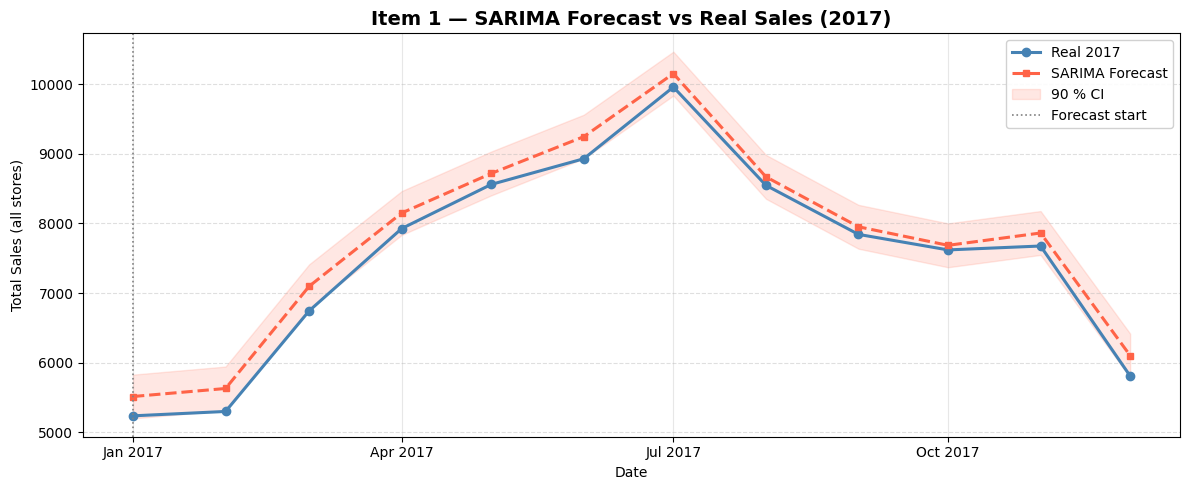

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

# Full history in the background (lighter)
#ax.plot(item1_monthly.index, item1_monthly.values,
 #       color='steelblue', linewidth=1.2, alpha=0.35, label='Historical (2013–2016)')

# 2017 real sales
ax.plot(test_ts.index, test_ts.values, color='steelblue', linewidth=2.2, marker='o', markersize=6, label='Real 2017')

# SARIMA prediction
ax.plot(pred_mean1.index, pred_mean1.values, color='tomato', linewidth=2.2, linestyle='--', marker='s', markersize=5, label='SARIMA Forecast')

# Confidence band
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0], pred_ci.iloc[:, 1],
                color='tomato', alpha=0.15, label='90 % CI')

ax.axvline(pd.Timestamp('2017-01-01'), color='grey',
           linestyle=':', linewidth=1.2, label='Forecast start')

ax.set_title('Item 1 — SARIMA Forecast vs Real Sales (2017)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales (all stores)')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(framealpha=0.9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae  = mean_absolute_error(test_ts, pred_mean1)
rmse = np.sqrt(mean_squared_error(test_ts, pred_mean1))
mape = (np.abs((test_ts.values - pred_mean1.values) / test_ts.values).mean()) * 100

print(f"MAE  : {mae:,.1f}")
print(f"RMSE : {rmse:,.1f}")
print(f"MAPE : {mape:.2f} %")

MAE  : 219.1
RMSE : 237.3
MAPE : 3.17 %


### Inventory

`inventory_needed = predicted_demand + safety_stock`

$$ SafetyStock = Z \times \sigma_{demand} \times LeadTime $$

- Z = service level (e.g. 1.65 for 95%)
- σ demand = standard deviation of demand
- LeadTime = replenishment time in days

| Service Level | Z-Value (Factor) | Risk of Stockout | Common Use Case |
| :--- | :---: | :---: | :--- |
| **80%** | 0.84 | 20% | Low turnover or low-margin products. |
| **90%** | 1.28 | 10% | Standard products. |
| **95%** | 1.65 | 5% | Most retail products. |
| **98%** | 2.05 | 2% | Star products or high priority. |
| **99%** | 2.33 | 1% | Critical items (medical, unique parts). |

In [ ]:
# We have monthly predictions aggregated across all stores.
# To split back per store, we compute each store's historical share of item 1 sales.

item1_train = df_train[(df_train['item'] == 1) & (df_train['date'].dt.year < 2017)].copy()

store_totals   = item1_train.groupby('store')['sales'].sum()
store_proportions = store_totals / store_totals.sum()   # sums to 1.0

print("Store sales proportions:")
print(store_proportions.round(4).to_string())

Store sales proportions:
store
1     0.0912
2     0.1281
3     0.1136
4     0.1044
5     0.0760
6     0.0764
7     0.0688
8     0.1228
9     0.1059
10    0.1128


In [ ]:
# sigma is computed on the daily sales of each store (item 1, training period)
# This captures store-level demand variability


#In supply chain projects, something like this is often used:
lead_time = 7

#95% service level
Z         = 1.65

safety_stocks = {}
for store_id, grp in item1_train.groupby('store'):
    sigma = grp['sales'].std()
    safety_stocks[store_id] = round(Z * sigma * np.sqrt(lead_time), 2)

safety_df = pd.DataFrame.from_dict(
    safety_stocks, orient='index', columns=['safety_stock']
)
safety_df.index.name = 'store'
print("Safety stock per store (units):")
print(safety_df.to_string())

Safety stock per store (units):
       safety_stock
store              
1             28.70
2             36.27
3             33.51
4             30.90
5             24.64
6             24.48
7             22.70
8             36.84
9             32.89
10            33.94


In [ ]:
records = []

for month_date, total_pred in pred_mean1.items():
    # Real monthly sales for this month (all stores, item 1)
    real_month = (
        df_train[
            (df_train['item'] == 1) &
            (df_train['date'].dt.year  == month_date.year) &
            (df_train['date'].dt.month == month_date.month)
        ]
        .groupby('store')['sales'].sum()
    )

    for store_id in range(1, 11):
        # Distribute predicted monthly sales by store proportion
        predicted_store = total_pred * store_proportions.get(store_id, 0)

        # Real sales for this store/month (may be 0 if not in training set)
        real_store = real_month.get(store_id, 0)

        ss = safety_stocks[store_id]
        inv_needed = predicted_store + ss

        records.append({
            'date'            : month_date,
            'store'           : store_id,
            'item'            : 1,
            'sales'           : round(real_store, 0),
            'predicted_sales' : round(predicted_store, 2),
            'safety_stock'    : ss,
            'inventory_needed': round(inv_needed, 2)
        })

inventory_df = pd.DataFrame(records).sort_values(['store', 'date']).reset_index(drop=True)
print(f"Shape: {inventory_df.shape}")
inventory_df.head(12)

Shape: (120, 7)


,date,store,item,sales,predicted_sales,safety_stock,inventory_needed
0,2017-01-01,1,1,485,502.62,28.7,531.32
1,2017-02-01,1,1,487,513.12,28.7,541.82
2,2017-03-01,1,1,561,646.98,28.7,675.68
3,2017-04-01,1,1,677,742.94,28.7,771.64
4,2017-05-01,1,1,773,794.77,28.7,823.47
5,2017-06-01,1,1,850,842.97,28.7,871.67
6,2017-07-01,1,1,873,925.53,28.7,954.23
7,2017-08-01,1,1,794,790.32,28.7,819.02
8,2017-09-01,1,1,736,724.90,28.7,753.60
9,2017-10-01,1,1,660,700.61,28.7,729.31


In [ ]:
# --- Monthly sigma per store (item 1, training period) ---
item1_monthly_store = (
    item1_train
    .groupby(['store', pd.Grouper(key='date', freq='MS')])['sales']
    .sum()
    .reset_index()
)

lead_time_months = 1   # 1-month replenishment lead time
Z                = 1.65

safety_stocks_monthly = {}
for store_id, grp in item1_monthly_store.groupby('store'):
    sigma = grp['sales'].std()                                        # monthly std
    safety_stocks_monthly[store_id] = round(Z * sigma * np.sqrt(lead_time_months), 2)

# --- Build records ---
records = []

for month_date, total_pred in pred_mean1.items():

    # Real monthly sales per store for this month
    real_month = (
        df_train[
            (df_train['item'] == 1) &
            (df_train['date'].dt.year  == month_date.year) &
            (df_train['date'].dt.month == month_date.month)
        ]
        .groupby('store')['sales'].sum()
    )

    for store_id in range(1, 11):
        predicted_store = total_pred * store_proportions.get(store_id, 0)
        real_store      = real_month.get(store_id, 0)

        ss         = safety_stocks_monthly[store_id]   # now in monthly units
        inv_needed = predicted_store + ss

        records.append({
            'date'            : month_date,
            'store'           : store_id,
            'item'            : 1,
            'sales'           : round(real_store, 0),
            'predicted_sales' : round(predicted_store, 2),
            'safety_stock'    : ss,
            'inventory_needed': round(inv_needed, 2)
        })

inventory_df = pd.DataFrame(records).sort_values(['store', 'date']).reset_index(drop=True)
print(f"Shape: {inventory_df.shape}")
inventory_df.head(12)

Shape: (120, 7)


,date,store,item,sales,predicted_sales,safety_stock,inventory_needed
0,2017-01-01,1,1,485,502.62,225.14,727.76
1,2017-02-01,1,1,487,513.12,225.14,738.26
2,2017-03-01,1,1,561,646.98,225.14,872.12
3,2017-04-01,1,1,677,742.94,225.14,968.08
4,2017-05-01,1,1,773,794.77,225.14,1019.91
5,2017-06-01,1,1,850,842.97,225.14,1068.11
6,2017-07-01,1,1,873,925.53,225.14,1150.67
7,2017-08-01,1,1,794,790.32,225.14,1015.46
8,2017-09-01,1,1,736,724.90,225.14,950.04
9,2017-10-01,1,1,660,700.61,225.14,925.75


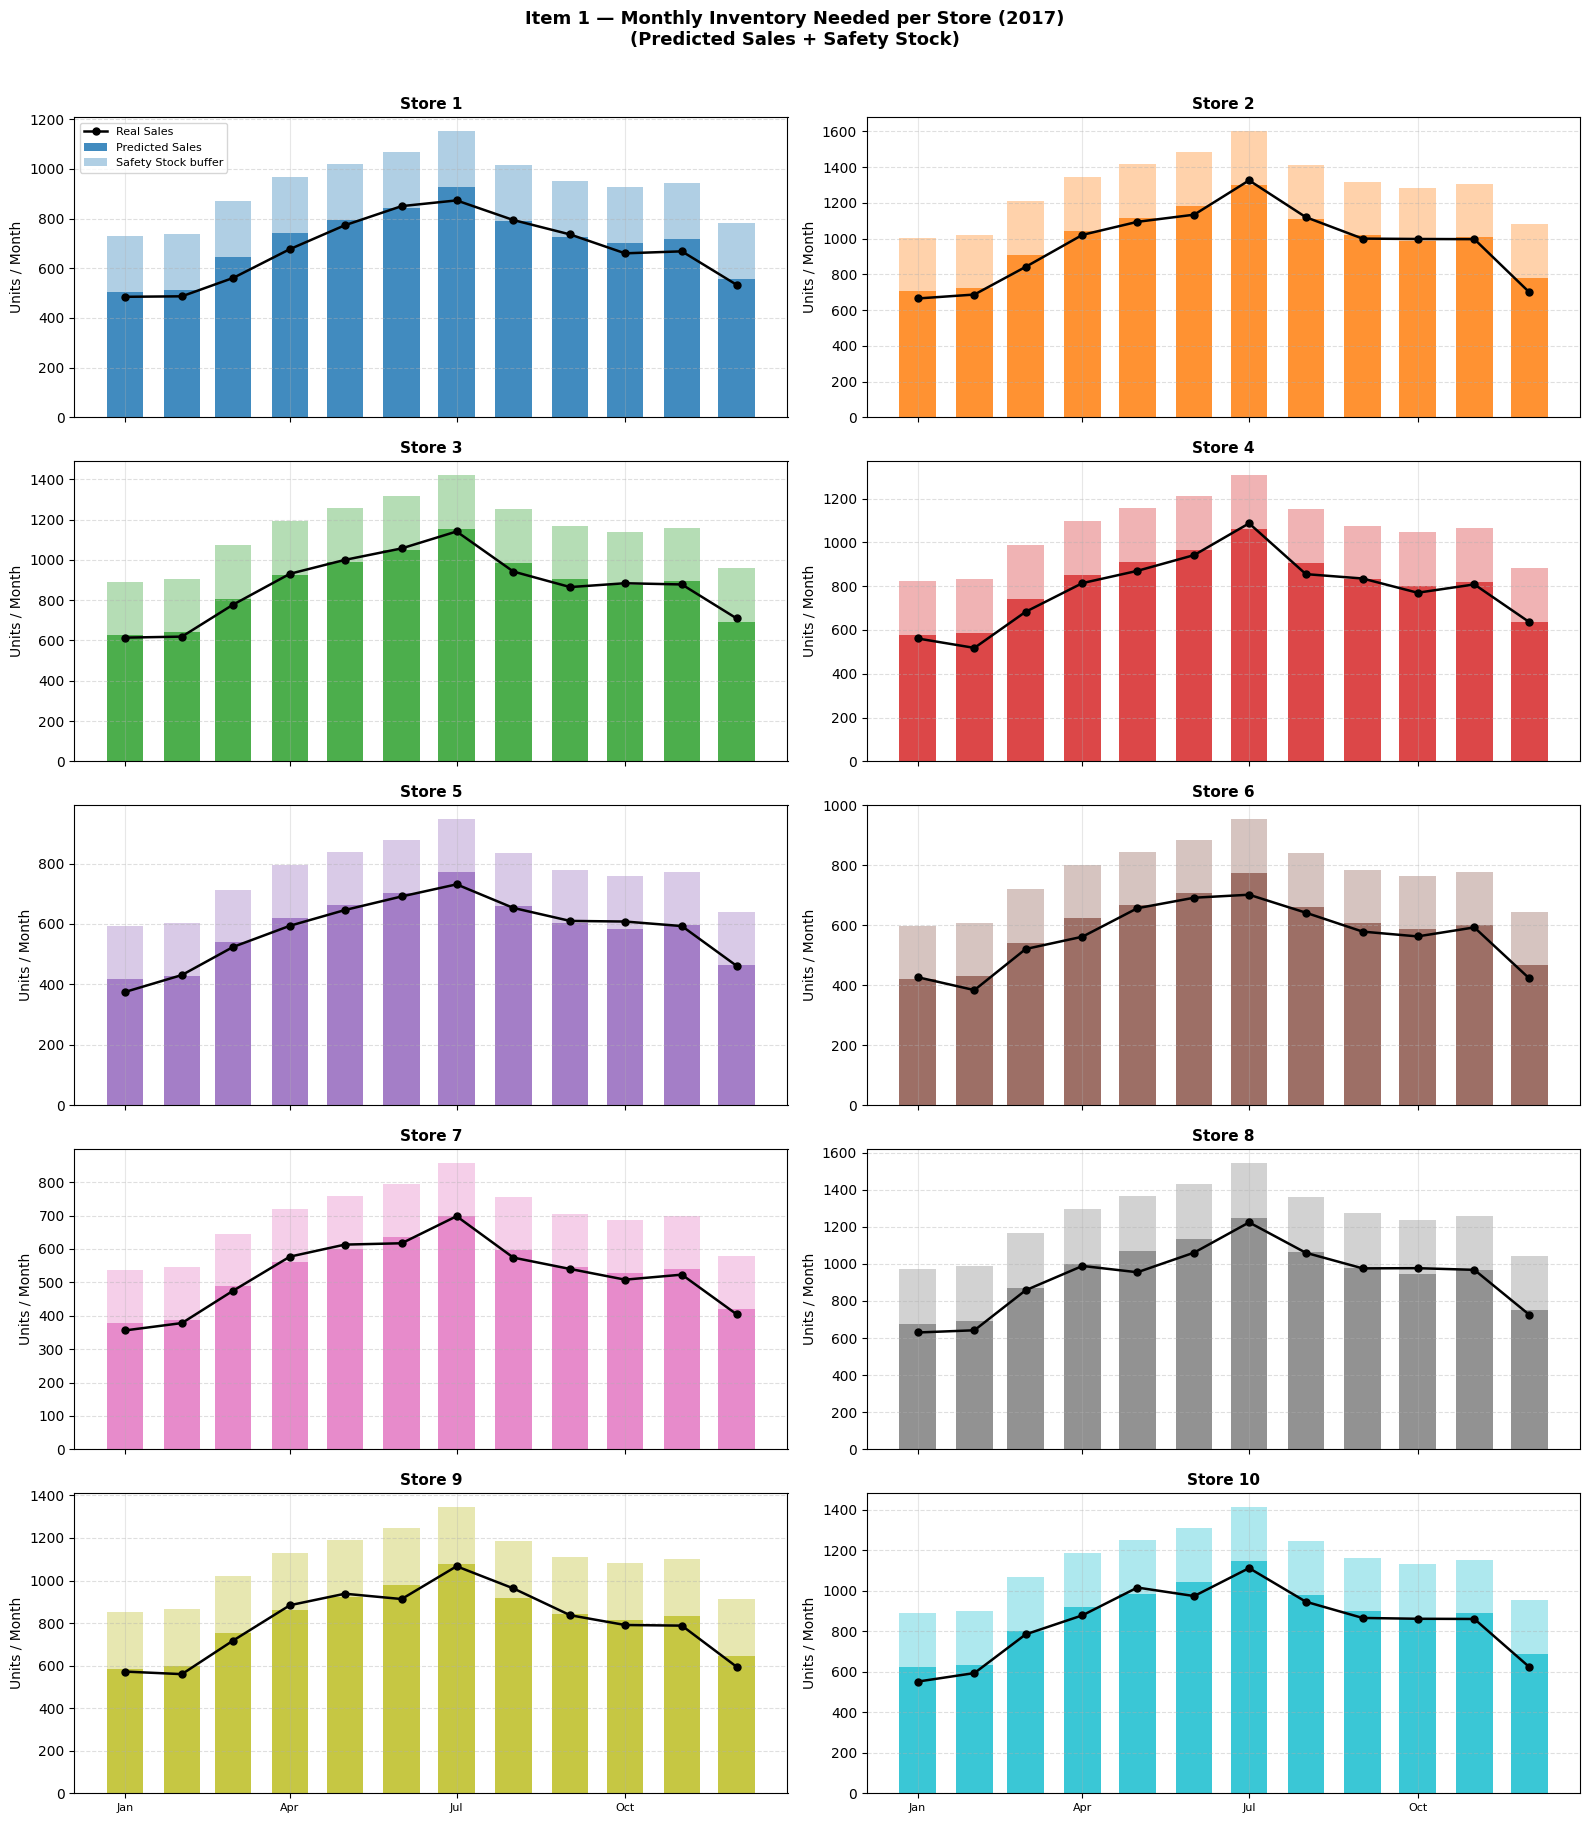

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(16, 18), sharex=True)
axes = axes.flatten()
colors = plt.cm.tab10.colors

for i, store_id in enumerate(range(1, 11)):
    ax  = axes[i]
    grp = inventory_df[inventory_df['store'] == store_id].set_index('date')

    # Stacked bar: predicted sales + safety stock on top
    ax.bar(grp.index, grp['predicted_sales'],
           width=20, color=colors[i], alpha=0.85, label='Predicted Sales')
    ax.bar(grp.index, grp['safety_stock'],
           width=20, color=colors[i], alpha=0.35, 
           bottom=grp['predicted_sales'], label='Safety Stock buffer')

    # Real sales line on top
    ax.plot(grp.index, grp['sales'],
            color='black', linewidth=1.8, marker='o', markersize=5,
            zorder=5, label='Real Sales')

    ax.set_title(f'Store {store_id}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Units / Month')
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    if i == 0:
        ax.legend(fontsize=8, loc='upper left')

fig.suptitle('Item 1 — Monthly Inventory Needed per Store (2017)\n(Predicted Sales + Safety Stock)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

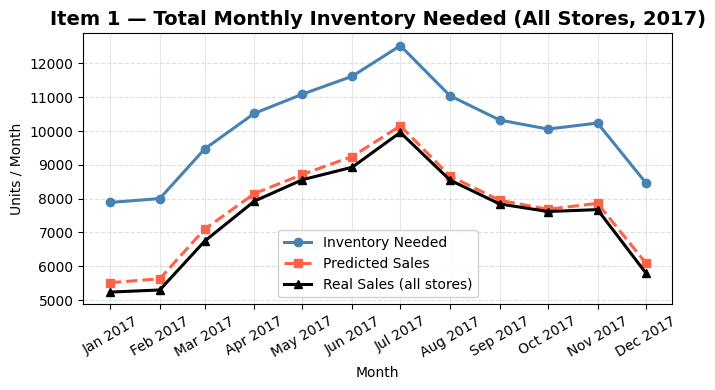

In [ ]:
monthly_summary = (
    inventory_df
    .groupby('date')[['inventory_needed', 'predicted_sales', 'safety_stock', 'sales']]
    .sum()
)

fig, ax = plt.subplots(figsize=(7, 4))

# Inventory Needed
ax.plot(monthly_summary.index, monthly_summary['inventory_needed'],
        color='steelblue', linewidth=2.2, marker='o', markersize=6,
        label='Inventory Needed')

# Predicted Sales
ax.plot(monthly_summary.index, monthly_summary['predicted_sales'],
        color='tomato', linewidth=2.2, linestyle='--', marker='s', markersize=6,
        label='Predicted Sales')

# Real Sales
ax.plot(monthly_summary.index, monthly_summary['sales'],
        color='black', linewidth=2.2, marker='^', markersize=6,
        label='Real Sales (all stores)')

ax.set_title('Item 1 — Total Monthly Inventory Needed (All Stores, 2017)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Units / Month')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=30)
ax.legend(framealpha=0.9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

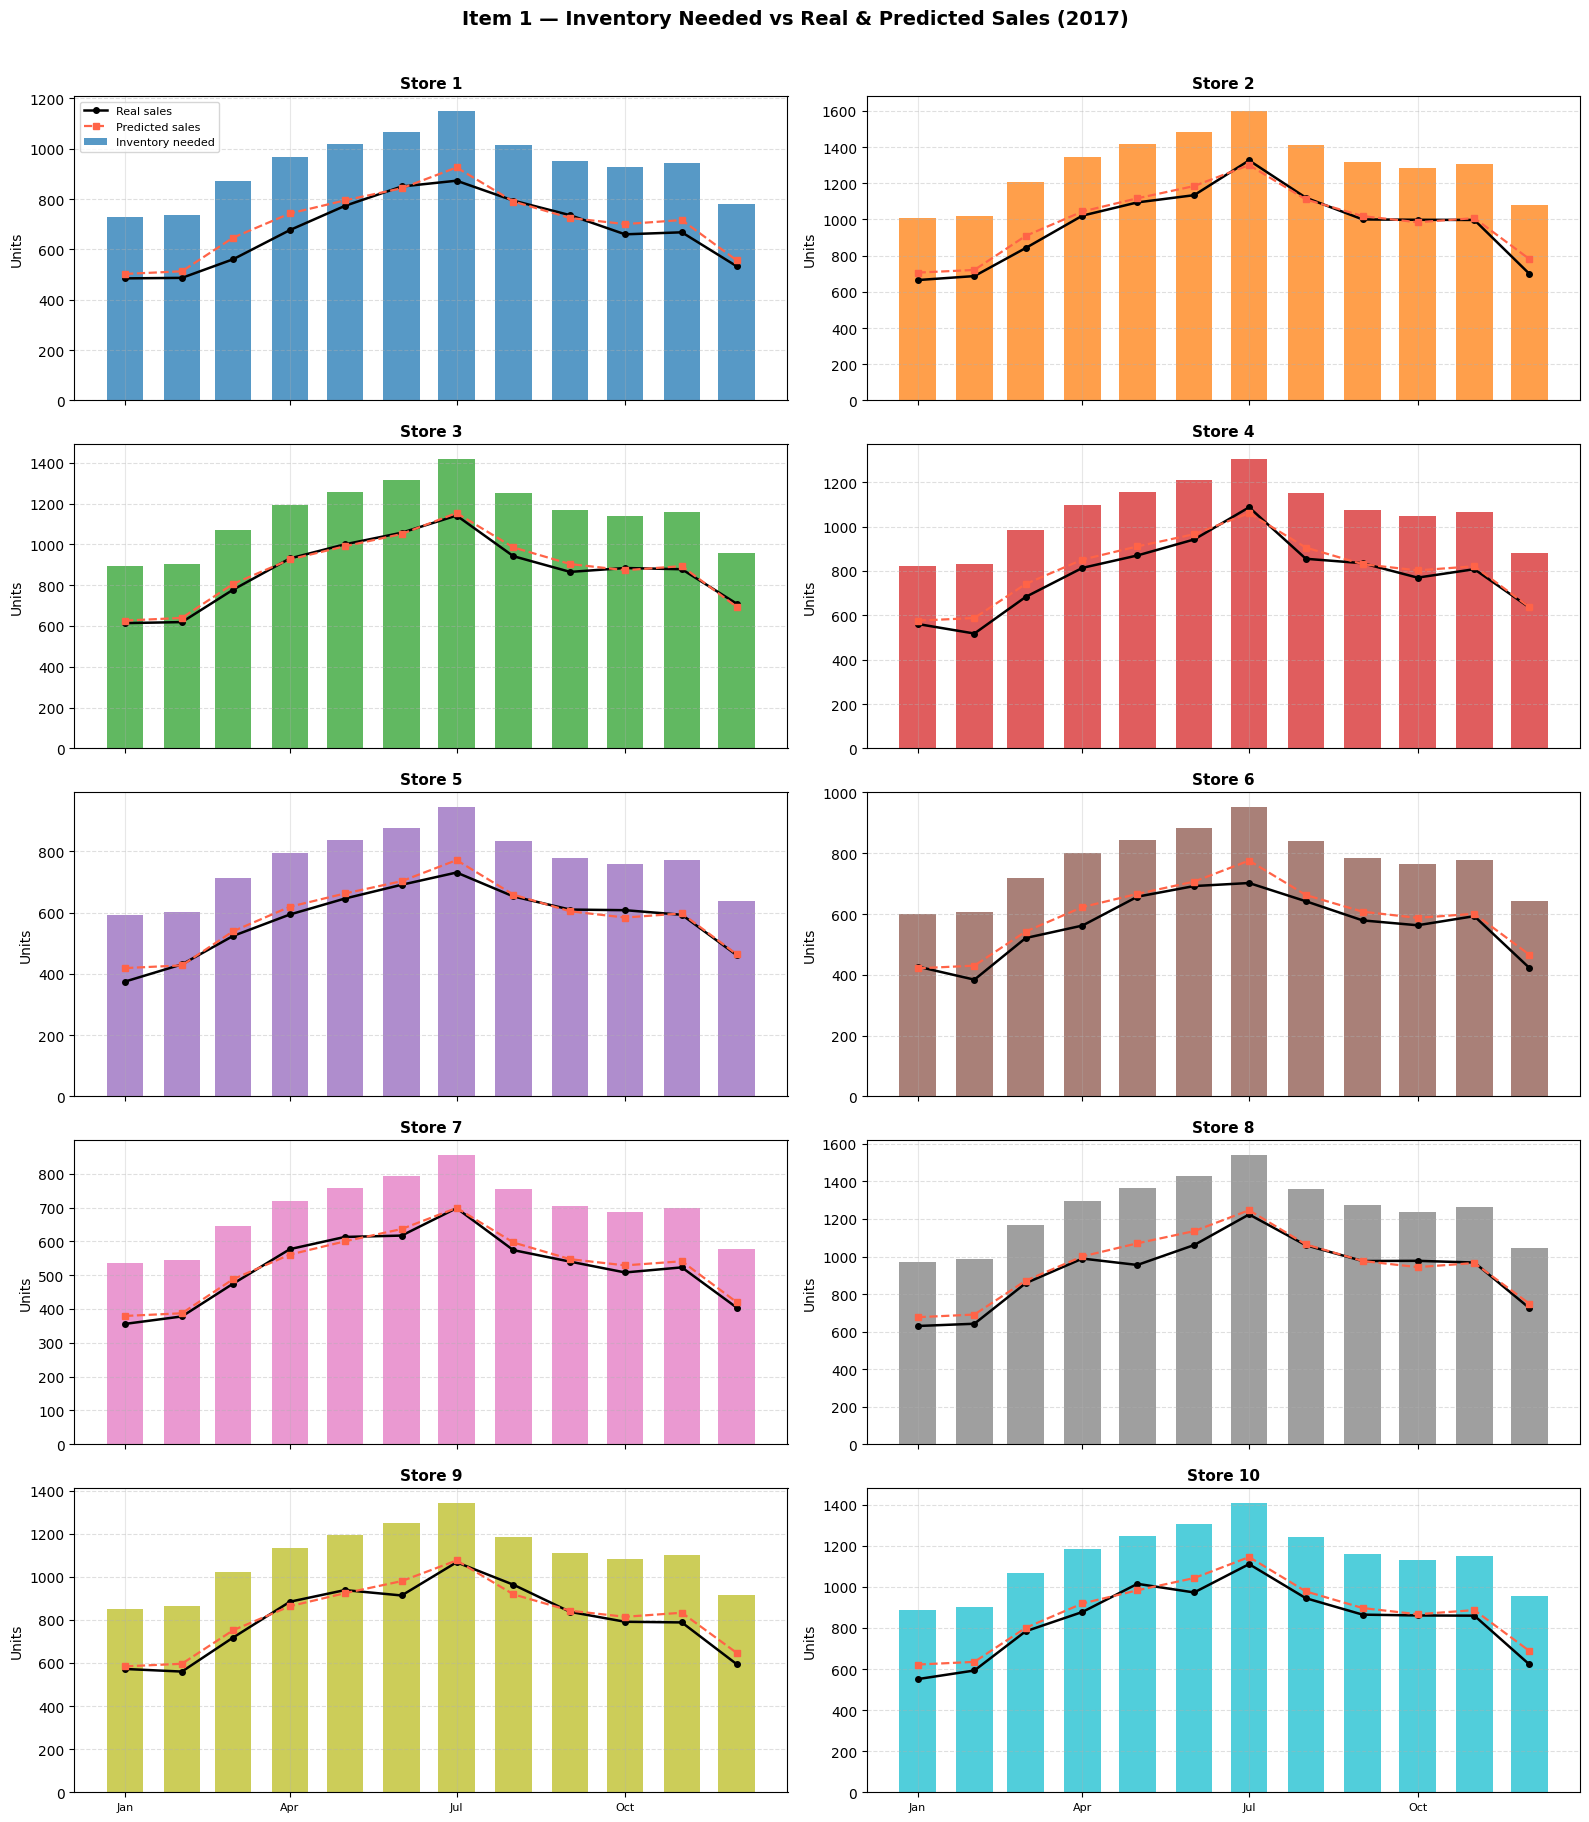

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(16, 18), sharex=True, sharey=False)
axes = axes.flatten()

colors = plt.cm.tab10.colors   # one distinct color per store

for i, store_id in enumerate(range(1, 11)):
    ax  = axes[i]
    grp = inventory_df[inventory_df['store'] == store_id].set_index('date')

    ax.bar(grp.index, grp['inventory_needed'],
           width=20, color=colors[i], alpha=0.75, label='Inventory needed')

    ax.plot(grp.index, grp['sales'],
            color='black', linewidth=1.8, marker='o', markersize=4,
            label='Real sales')

    ax.plot(grp.index, grp['predicted_sales'],
            color='tomato', linewidth=1.6, linestyle='--', marker='s', markersize=4,
            label='Predicted sales')

    ax.set_title(f'Store {store_id}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Units')
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    if i == 0:
        ax.legend(fontsize=8, loc='upper left')

fig.suptitle('Item 1 — Inventory Needed vs Real & Predicted Sales (2017)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

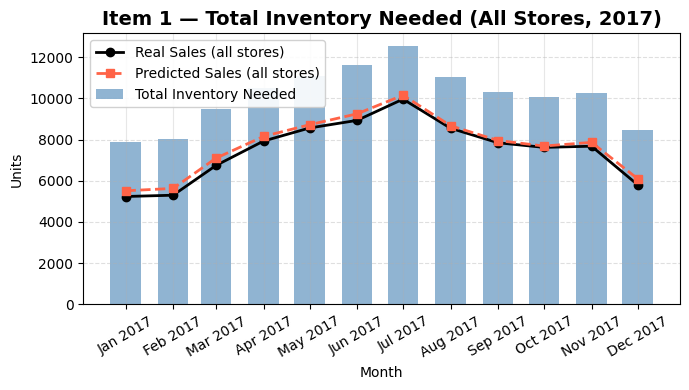

In [ ]:
monthly_inv = inventory_df.groupby('date')[['inventory_needed', 'sales', 'predicted_sales']].sum()

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(monthly_inv.index, monthly_inv['inventory_needed'],
       width=20, color='steelblue', alpha=0.6, label='Total Inventory Needed')

ax.plot(monthly_inv.index, monthly_inv['sales'],
        color='black', linewidth=2, marker='o', markersize=6, label='Real Sales (all stores)')

ax.plot(monthly_inv.index, monthly_inv['predicted_sales'],
        color='tomato', linewidth=2, linestyle='--', marker='s', markersize=6,
        label='Predicted Sales (all stores)')

ax.set_title('Item 1 — Total Inventory Needed (All Stores, 2017)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Units')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=30)
ax.legend(framealpha=0.9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

______________________________________________________________________________________________

______________________________________________________________________________________________

In [ ]:
# Convert 'date' column to datetime objects
df_train['date'] = pd.to_datetime(df_train['date'])
df_val['date'] = pd.to_datetime(df_val['date'])

# Set date as index for easier time series plotting (optional but good practice)
df_train_indexed = df_train.set_index('date')
df_val_indexed = df_val.set_index('date')
#df_test_indexed = df_train_indexed.loc['2017']
#df_train_indexed = df_train_indexed.drop(df_train_indexed.loc['2017'].index)

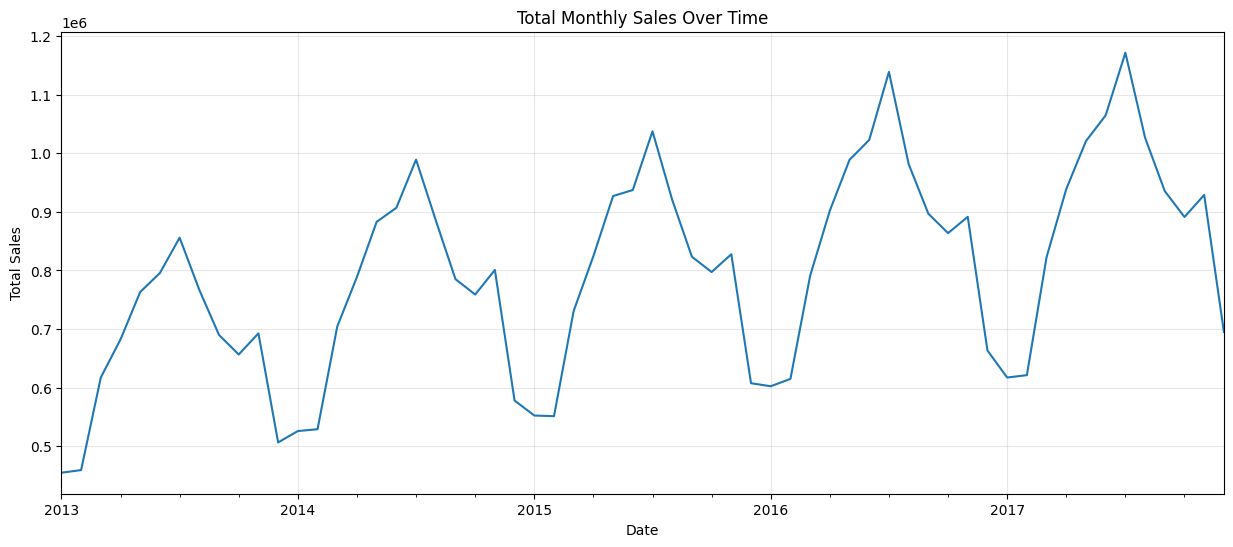

In [ ]:
# Plot total sales over time
plt.figure(figsize=(15, 6))
df_train_indexed['sales'].resample('M').sum().plot(title='Total Monthly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

In [ ]:
train_ts = item1_monthly[item1_monthly.index.year < 2017]
test_ts  = item1_monthly[item1_monthly.index.year == 2017]

print(f"Train: {len(train_ts)} months  |  Test (2017): {len(test_ts)} months")

Train: 48 months  |  Test (2017): 12 months


In [ ]:
model = SARIMAX(
    train_ts,
    order=(1, 1, 1),             # (p, d, q)
    seasonal_order=(1, 1, 1, 12),# (P, D, Q, s)
    enforce_stationarity=False,
    enforce_invertibility=False
)

result = model.fit(disp=False)
print(result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              sales   No. Observations:                   48
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -140.448
Date:                            Wed, 18 Mar 2026   AIC                            290.897
Time:                                    13:54:14   BIC                            296.119
Sample:                                01-01-2013   HQIC                           292.030
                                     - 12-01-2016                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0431      0.345      0.125      0.901      -0.633       0.719
ma.L1         -1.0000      0.360   

<Figure size 1500x600 with 0 Axes>

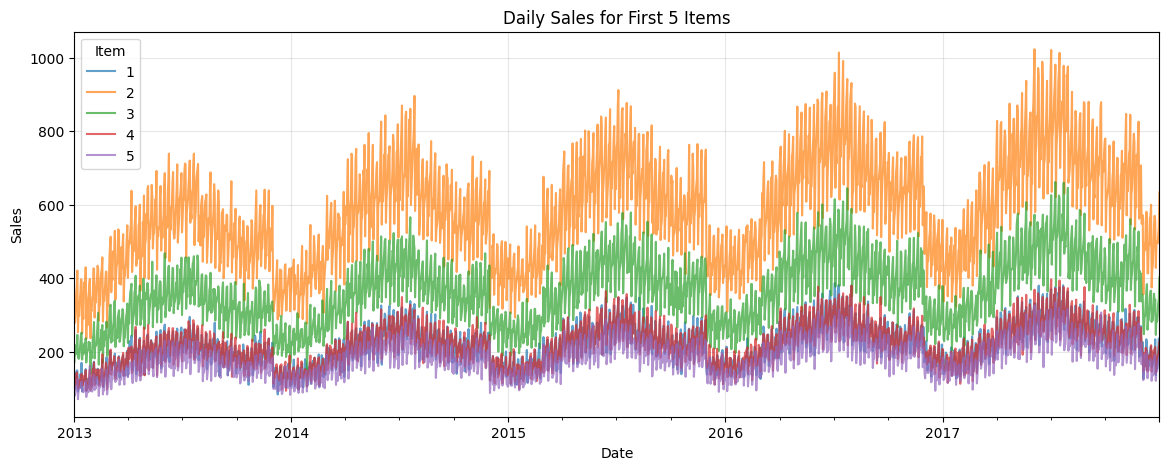

In [ ]:
# Plot average daily sales per item (first few items for clarity)
plt.figure(figsize=(15, 6))
df_train.groupby(['date', 'item'])['sales'].sum().unstack().iloc[:, :5].plot(title='Daily Sales for First 5 Items', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend(title='Item')
plt.grid(True)
plt.show()

Tenemos 5 productos/items, de los cuales queremos saber cuanto necesitamos tener en almacen para suplir el inventario en las 10 tiendas, por lo que haremos una prediccion por cada producto para suplir la demanda

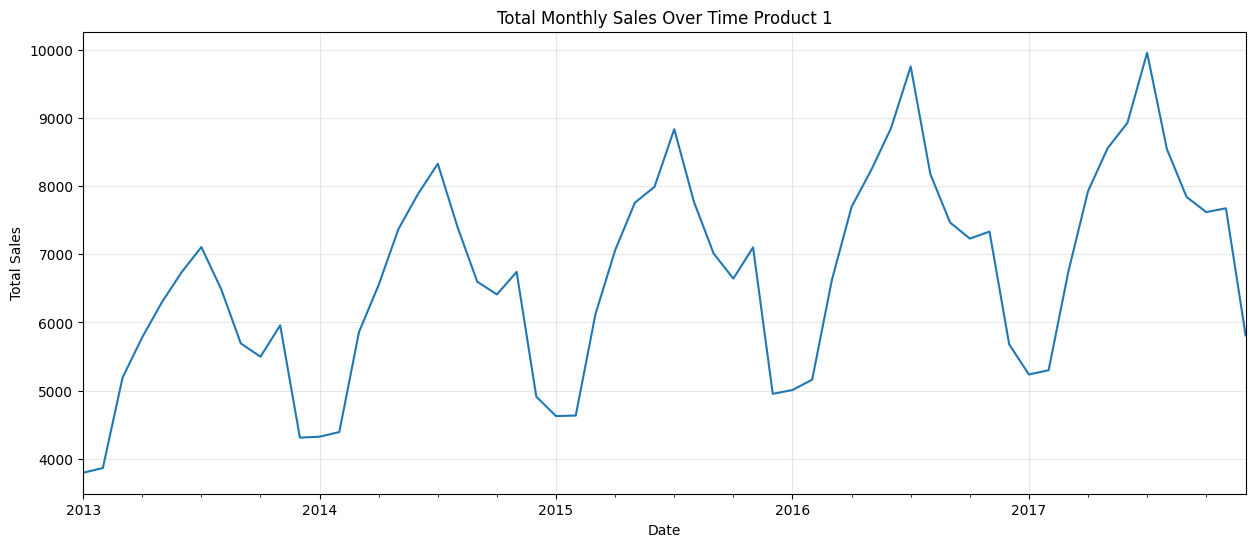

In [ ]:
lead_time = 7
Z = 1.65

#item = 1
item = 1
df_train_product_1 = df_train_indexed[(df_train_indexed["item"]==item)]
df_train_product_1 = df_train_product_1.sort_index()

sigma = df_train_product_1["sales"].std()
safety_stock = Z * sigma * np.sqrt(lead_time)
inventory_needed = df_train_product_1['sales'] + safety_stock

# Plot total sales over time
plt.figure(figsize=(15, 6))
df_train_product_1['sales'].resample('M').sum().plot(title='Total Monthly Sales Over Time Product 1')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()


In [ ]:
#item = 2

# Keep item 1 only, sum sales across all 10 stores per day
item2 = df_train_indexed[df_train_indexed['item'] == 2].copy()
item2_daily = item2.groupby('date')['sales'].sum()

# Resample to monthly totals
item2_monthly = item2_daily.resample('MS').sum()   # 'MS' = Month Start

print(f"Date range : {item2_monthly.index[0].date()} → {item2_monthly.index[-1].date()}")
print(f"Total months: {len(item2_monthly)}")
item2_monthly.head()

Date range : 2013-01-01 → 2017-12-01
Total months: 60


date
2013-01-01    10379
2013-02-01    10338
2013-03-01    13933
2013-04-01    14938
2013-05-01    17179
Freq: MS, Name: sales, dtype: int64

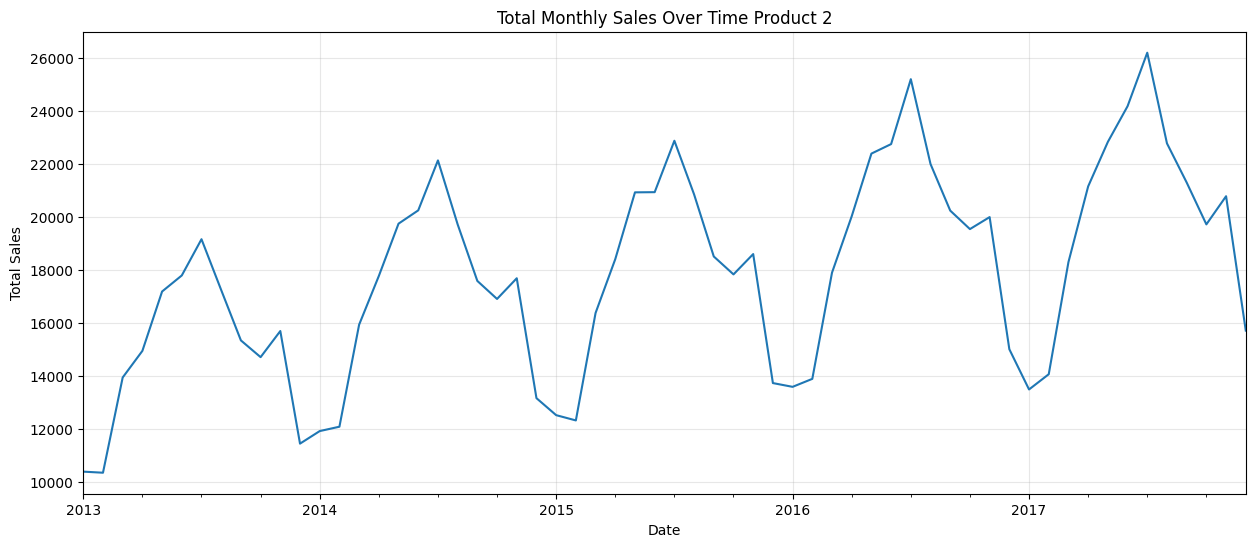

In [ ]:

# Plot total sales over time
plt.figure(figsize=(15, 6))
item2_monthly.plot(title='Total Monthly Sales Over Time Product 2')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

In [ ]:
train_ts = item2_monthly[item2_monthly.index.year < 2017]
test_ts  = item2_monthly[item2_monthly.index.year == 2017]

print(f"Train: {len(train_ts)} months  |  Test (2017): {len(test_ts)} months")

Train: 48 months  |  Test (2017): 12 months


In [ ]:
model = SARIMAX(
    train_ts,
    order=(1, 1, 1),             # (p, d, q)
    seasonal_order=(1, 1, 1, 12),# (P, D, Q, s)
    enforce_stationarity=False,
    enforce_invertibility=False
)

result = model.fit(disp=False)
print(result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              sales   No. Observations:                   48
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -149.935
Date:                            Wed, 18 Mar 2026   AIC                            309.871
Time:                                    13:57:04   BIC                            315.094
Sample:                                01-01-2013   HQIC                           311.004
                                     - 12-01-2016                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2143      0.182      1.175      0.240      -0.143       0.572
ma.L1         -1.0000      0.305   

In [ ]:
# Forecast exactly the 12 months of 2017
forecast = result.get_forecast(steps=len(test_ts))
pred_mean2 = forecast.predicted_mean
pred_ci   = forecast.conf_int(alpha=0.10)   # 90 % confidence interval

pred_mean2.index = test_ts.index   # align index
pred_ci.index   = test_ts.index

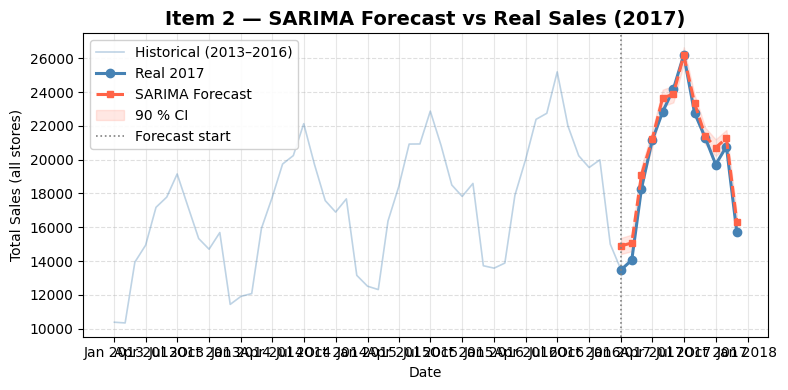

In [ ]:
fig, ax = plt.subplots(figsize=(8,4))


# Full history in the background (lighter)
ax.plot(item2_monthly.index, item2_monthly.values,
        color='steelblue', linewidth=1.2, alpha=0.35, label='Historical (2013–2016)')

# 2017 real sales
ax.plot(test_ts.index, test_ts.values,
        color='steelblue', linewidth=2.2, marker='o', markersize=6, label='Real 2017')

# SARIMA prediction
ax.plot(pred_mean2.index, pred_mean2.values,
        color='tomato', linewidth=2.2, linestyle='--', marker='s', markersize=5,
        label='SARIMA Forecast')

# Confidence band
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0], pred_ci.iloc[:, 1],
                color='tomato', alpha=0.15, label='90 % CI')

ax.axvline(pd.Timestamp('2017-01-01'), color='grey',
           linestyle=':', linewidth=1.2, label='Forecast start')

ax.set_title('Item 2 — SARIMA Forecast vs Real Sales (2017)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales (all stores)')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(framealpha=0.9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Date range : 2013-01-01 → 2017-12-01
Total months: 60


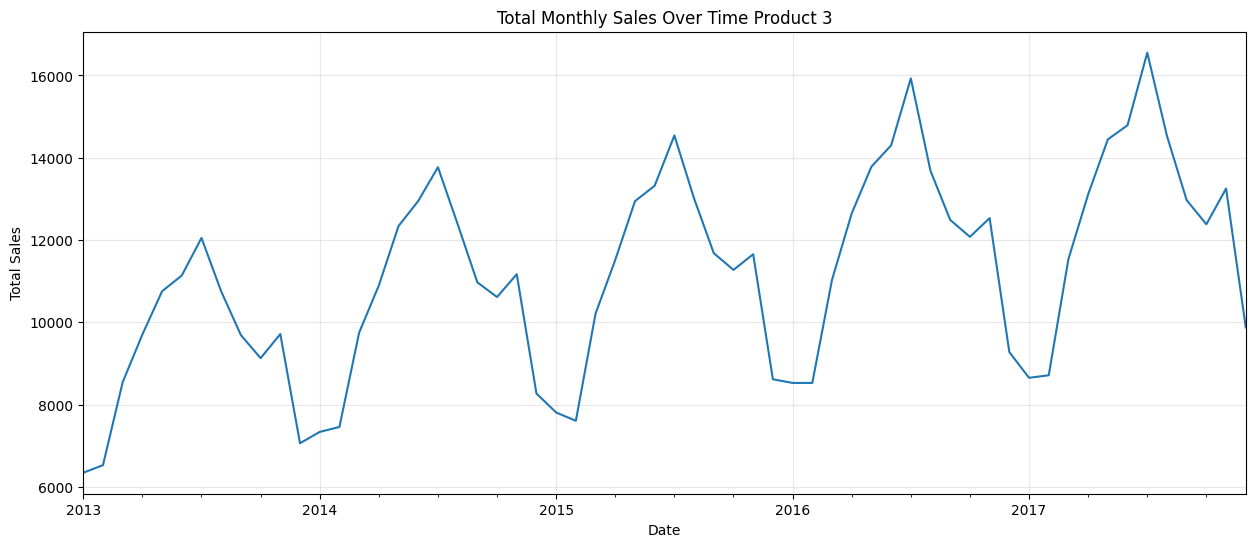

In [ ]:
#item = 3
# Keep item 1 only, sum sales across all 10 stores per day
item3 = df_train_indexed[df_train_indexed['item'] == 3].copy()
item3_daily = item3.groupby('date')['sales'].sum()

# Resample to monthly totals
item3_monthly = item3_daily.resample('MS').sum()   # 'MS' = Month Start

print(f"Date range : {item3_monthly.index[0].date()} → {item3_monthly.index[-1].date()}")
print(f"Total months: {len(item3_monthly)}")
item3_monthly.head()

# Plot total sales over time
plt.figure(figsize=(15, 6))
item3_monthly.plot(title='Total Monthly Sales Over Time Product 3')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

Train: 48 months  |  Test (2017): 12 months
                                     SARIMAX Results                                      
Dep. Variable:                              sales   No. Observations:                   48
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -140.773
Date:                            Wed, 18 Mar 2026   AIC                            291.546
Time:                                    13:54:22   BIC                            296.768
Sample:                                01-01-2013   HQIC                           292.679
                                     - 12-01-2016                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0660      0.231      0.285      0.775      -0.387    

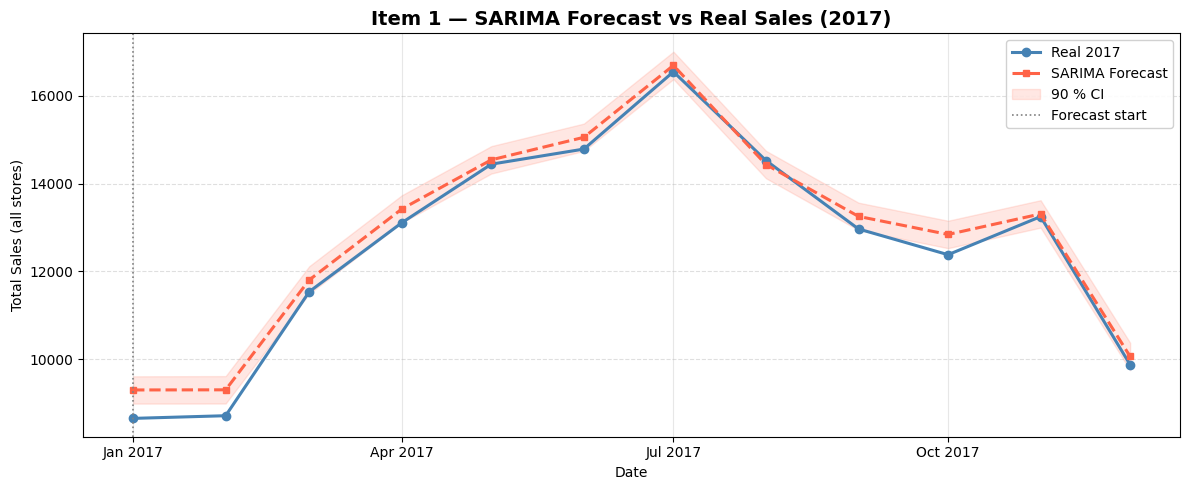

In [ ]:
train_ts = item3_monthly[item3_monthly.index.year < 2017]
test_ts  = item3_monthly[item3_monthly.index.year == 2017]

print(f"Train: {len(train_ts)} months  |  Test (2017): {len(test_ts)} months")

model = SARIMAX(
    train_ts,
    order=(1, 1, 1),             # (p, d, q)
    seasonal_order=(1, 1, 1, 12),# (P, D, Q, s)
    enforce_stationarity=False,
    enforce_invertibility=False
)

result = model.fit(disp=False)
print(result.summary())


# Forecast exactly the 12 months of 2017
forecast = result.get_forecast(steps=len(test_ts))
pred_mean3 = forecast.predicted_mean
pred_ci   = forecast.conf_int(alpha=0.10)   # 90 % confidence interval

pred_mean3.index = test_ts.index   # align index
pred_ci.index   = test_ts.index

fig, ax = plt.subplots(figsize=(12, 5))

# 2017 real sales
ax.plot(test_ts.index, test_ts.values,
        color='steelblue', linewidth=2.2, marker='o', markersize=6, label='Real 2017')

# SARIMA prediction
ax.plot(pred_mean3.index, pred_mean3.values,
        color='tomato', linewidth=2.2, linestyle='--', marker='s', markersize=5,
        label='SARIMA Forecast')

# Confidence band
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0], pred_ci.iloc[:, 1],
                color='tomato', alpha=0.15, label='90 % CI')

ax.axvline(pd.Timestamp('2017-01-01'), color='grey',
           linestyle=':', linewidth=1.2, label='Forecast start')

ax.set_title('Item 1 — SARIMA Forecast vs Real Sales (2017)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales (all stores)')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(framealpha=0.9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



Date range : 2013-01-01 → 2017-12-01
Total months: 60


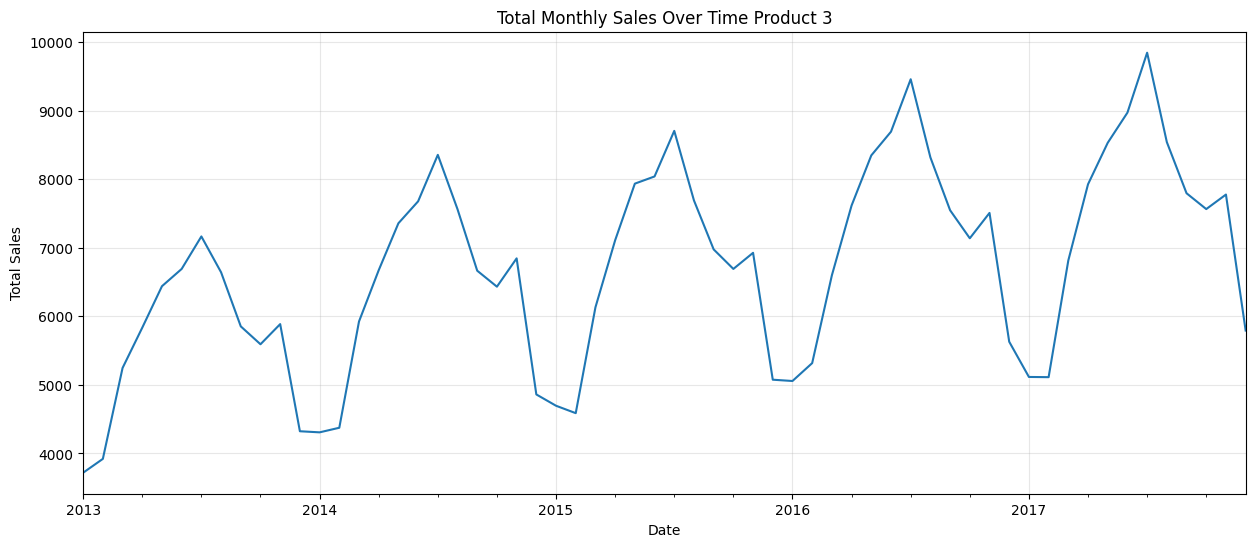

In [ ]:
#item = 4
# Keep item 1 only, sum sales across all 10 stores per day
item4 = df_train_indexed[df_train_indexed['item'] == 4].copy()
item4_daily = item4.groupby('date')['sales'].sum()

# Resample to monthly totals
item4_monthly = item4_daily.resample('MS').sum()   # 'MS' = Month Start

print(f"Date range : {item4_monthly.index[0].date()} → {item4_monthly.index[-1].date()}")
print(f"Total months: {len(item4_monthly)}")
item4_monthly.head()

# Plot total sales over time
plt.figure(figsize=(15, 6))
item4_monthly.plot(title='Total Monthly Sales Over Time Product 3')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

Train: 48 months  |  Test (2017): 12 months
                       ExponentialSmoothing Model Results                       
Dep. Variable:                    sales   No. Observations:                   48
Model:             ExponentialSmoothing   SSE                         740543.501
Optimized:                         True   AIC                            494.909
Trend:                         Additive   BIC                            524.848
Seasonal:                      Additive   AICC                           518.495
Seasonal Periods:                    12   Date:                 Wed, 18 Mar 2026
Box-Cox:                          False   Time:                         14:01:16
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.8565897                alpha   

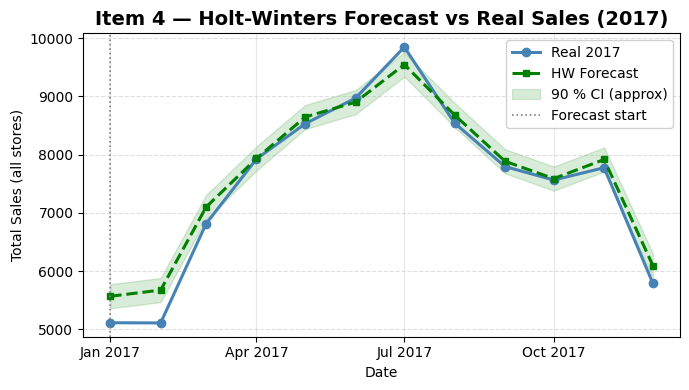

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

train_ts = item4_monthly[item4_monthly.index.year < 2017]
test_ts  = item4_monthly[item4_monthly.index.year == 2017]

print(f"Train: {len(train_ts)} months  |  Test (2017): {len(test_ts)} months")

# Holt-Winters model (additive trend + seasonality)
model = ExponentialSmoothing(
    train_ts,
    trend='add',
    seasonal='add',
    seasonal_periods=12
)

result = model.fit()
print(result.summary())

# Forecast 2017
pred_mean4 = result.forecast(steps=len(test_ts))
pred_mean4.index = test_ts.index

# Approximate confidence interval (optional, since HW doesn't provide it natively)
residuals = train_ts - result.fittedvalues
sigma = residuals.std()
z = 1.65  # ~90% CI

pred_ci_lower = pred_mean4 - z * sigma
pred_ci_upper = pred_mean4 + z * sigma

fig, ax = plt.subplots(figsize=(7, 4))

# Real 2017
ax.plot(test_ts.index, test_ts.values,
        color='steelblue', linewidth=2.2, marker='o', markersize=6, label='Real 2017')

# Forecast
ax.plot(pred_mean4.index, pred_mean4.values,
        color='green', linewidth=2.2, linestyle='--', marker='s', markersize=5,
        label='HW Forecast')

# Confidence band
ax.fill_between(pred_mean4.index,
                pred_ci_lower, pred_ci_upper,
                color='green', alpha=0.15, label='90 % CI (approx)')

ax.axvline(pd.Timestamp('2017-01-01'), color='grey',
           linestyle=':', linewidth=1.2, label='Forecast start')

ax.set_title('Item 4 — Holt-Winters Forecast vs Real Sales (2017)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales (all stores)')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(framealpha=0.9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Date range : 2013-01-01 → 2017-12-01
Total months: 60


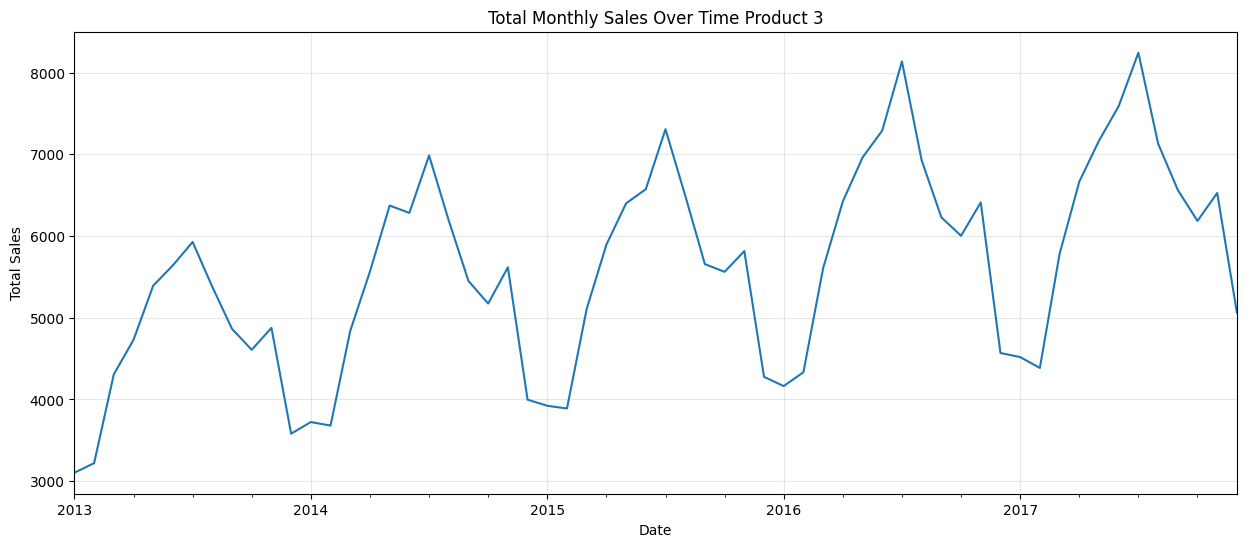

In [ ]:
#item = 5
# Keep item 1 only, sum sales across all 10 stores per day
item5 = df_train_indexed[df_train_indexed['item'] == 5].copy()
item5_daily = item5.groupby('date')['sales'].sum()

# Resample to monthly totals
item5_monthly = item5_daily.resample('MS').sum()   # 'MS' = Month Start

print(f"Date range : {item5_monthly.index[0].date()} → {item5_monthly.index[-1].date()}")
print(f"Total months: {len(item5_monthly)}")
item5_monthly.head()

# Plot total sales over time
plt.figure(figsize=(15, 6))
item5_monthly.plot(title='Total Monthly Sales Over Time Product 3')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

Train: 48 months  |  Test (2017): 12 months
                       ExponentialSmoothing Model Results                       
Dep. Variable:                    sales   No. Observations:                   48
Model:             ExponentialSmoothing   SSE                         893884.150
Optimized:                         True   AIC                            503.942
Trend:                         Additive   BIC                            533.881
Seasonal:                      Additive   AICC                           527.528
Seasonal Periods:                    12   Date:                 Wed, 18 Mar 2026
Box-Cox:                          False   Time:                         13:54:24
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.5949380                alpha   

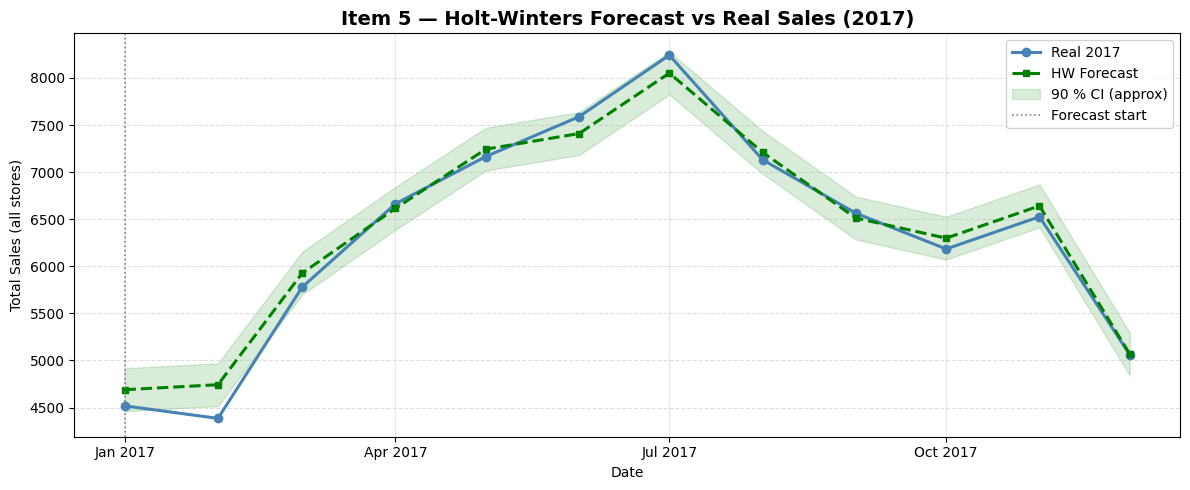

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

train_ts = item5_monthly[item5_monthly.index.year < 2017]
test_ts  = item5_monthly[item5_monthly.index.year == 2017]

print(f"Train: {len(train_ts)} months  |  Test (2017): {len(test_ts)} months")

# Holt-Winters model (additive trend + seasonality)
model = ExponentialSmoothing(
    train_ts,
    trend='add',
    seasonal='add',
    seasonal_periods=12
)

result = model.fit()
print(result.summary())

# Forecast 2017
pred_mean5 = result.forecast(steps=len(test_ts))
pred_mean5.index = test_ts.index

# Approximate confidence interval (optional, since HW doesn't provide it natively)
residuals = train_ts - result.fittedvalues
sigma = residuals.std()
z = 1.65  # ~90% CI

pred_ci_lower = pred_mean5 - z * sigma
pred_ci_upper = pred_mean5 + z * sigma

fig, ax = plt.subplots(figsize=(12, 5))

# Real 2017
ax.plot(test_ts.index, test_ts.values,
        color='steelblue', linewidth=2.2, marker='o', markersize=6, label='Real 2017')

# Forecast
ax.plot(pred_mean5.index, pred_mean5.values,
        color='green', linewidth=2.2, linestyle='--', marker='s', markersize=5,
        label='HW Forecast')

# Confidence band
ax.fill_between(pred_mean5.index,
                pred_ci_lower, pred_ci_upper,
                color='green', alpha=0.15, label='90 % CI (approx)')

ax.axvline(pd.Timestamp('2017-01-01'), color='grey',
           linestyle=':', linewidth=1.2, label='Forecast start')

ax.set_title('Item 5 — Holt-Winters Forecast vs Real Sales (2017)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales (all stores)')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(framealpha=0.9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## All stores

In [ ]:
# Keep item 1 only, sum sales across all 10 stores per day
all_items = df_train_indexed.copy()
all_items_daily = all_items.groupby('date')['sales'].sum()


print(f"Date range : {all_items_daily.index[0].date()} → {all_items_daily.index[-1].date()}")
print(f"Total months: {len(all_items_daily)}")
all_items_daily.head()

Date range : 2013-01-01 → 2017-12-31
Total months: 1826


date
2013-01-01    13696
2013-01-02    13678
2013-01-03    14488
2013-01-04    15677
2013-01-05    16237
Name: sales, dtype: int64

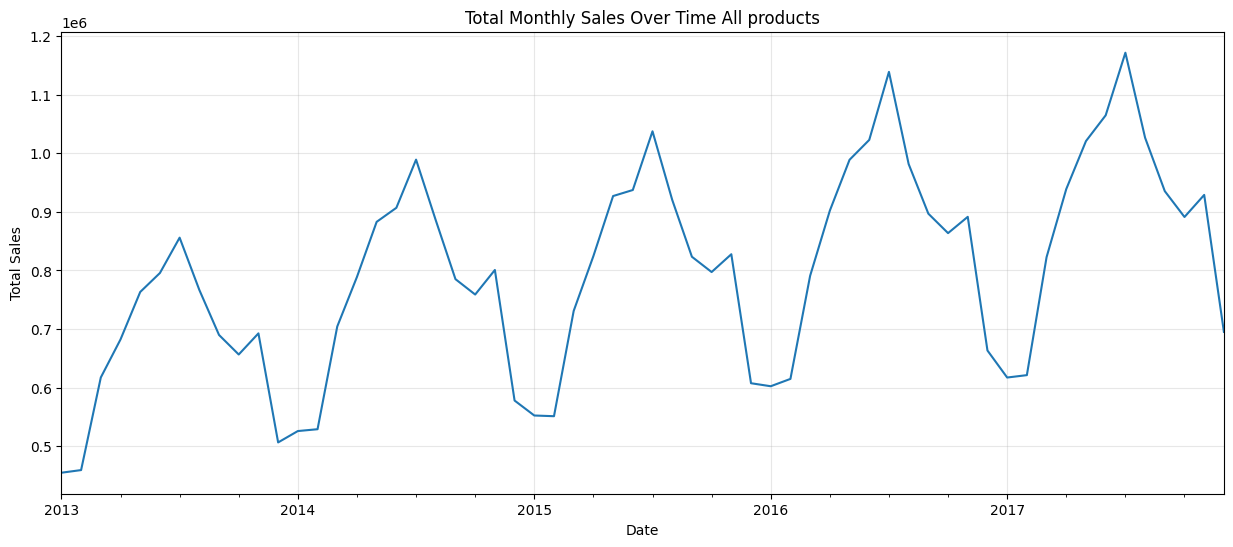

In [ ]:
# Resample to monthly totals
all_items_monthly = all_items_daily.resample('MS').sum() 
# Plot total sales over time
plt.figure(figsize=(15, 6))
all_items_monthly.plot(title='Total Monthly Sales Over Time All products')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

In [ ]:
from xgboost import XGBRegressor

# ── 1. Daily series for item 5 ──────────────────────────────────────────────
all_items_daily = df_train.groupby('date')['sales'].sum()
all_items_daily.index = pd.to_datetime(all_items_daily.index)

train_daily = all_items_daily[all_items_daily.index.year < 2017]   # ~1460 rows
test_daily  = all_items_daily[all_items_daily.index.year == 2017]  #  ~365 rows

print(f"Train: {len(train_daily)} days  |  Test (2017): {len(test_daily)} days")

Train: 1461 days  |  Test (2017): 365 days


In [ ]:
# ── 2. Feature engineering ───────────────────────────────────────────────────
def create_features(series, lags=30):
    df = pd.DataFrame({'y': series})
    for lag in range(1, lags + 1):
        df[f'lag_{lag}'] = df['y'].shift(lag)
    df['month']      = df.index.month
    df['dayofweek']  = df.index.dayofweek
    df['dayofyear']  = df.index.dayofyear
    df['weekofyear'] = df.index.isocalendar().week.astype(int)
    return df.dropna()

lags     = 30
train_df = create_features(train_daily, lags)

X_train  = train_df.drop(columns='y')
y_train  = train_df['y']

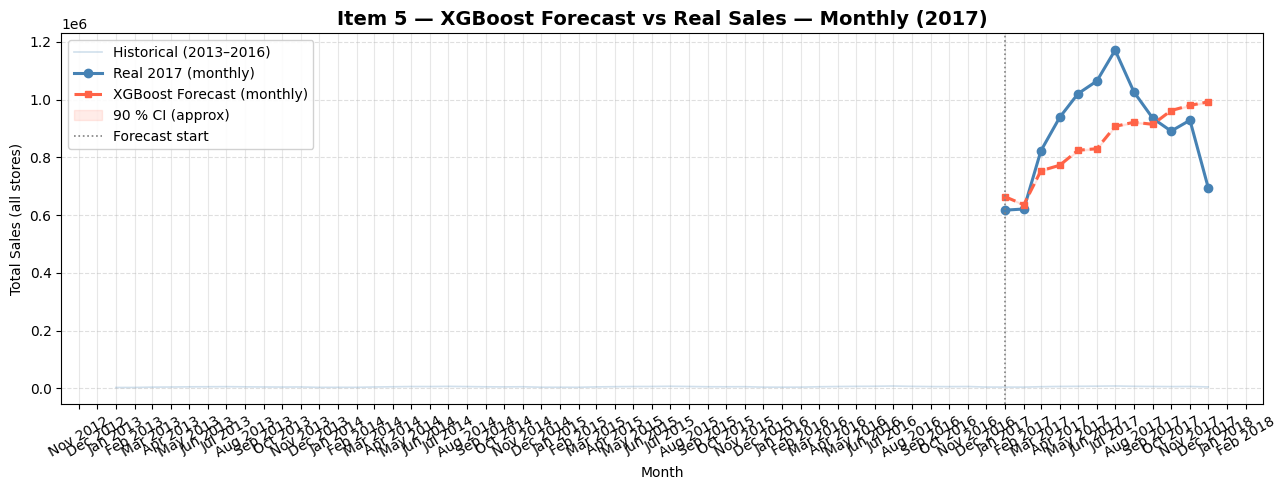

In [ ]:
# ── 3. Model ─────────────────────────────────────────────────────────────────
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)
model.fit(X_train, y_train)

# ── 4. Recursive daily forecast for 2017 ─────────────────────────────────────
history = list(train_daily.values)
preds   = []

for i in range(len(test_daily)):
    x_input    = history[-lags:]
    x_features = pd.DataFrame(
        [x_input], columns=[f'lag_{j}' for j in range(1, lags + 1)]
    )
    current_date                  = test_daily.index[i]
    x_features['month']           = current_date.month
    x_features['dayofweek']       = current_date.dayofweek
    x_features['dayofyear']       = current_date.dayofyear
    x_features['weekofyear']      = int(current_date.isocalendar()[1])

    yhat = model.predict(x_features)[0]
    preds.append(yhat)
    history.append(yhat)

pred_daily = pd.Series(preds, index=test_daily.index)

# ── 5. Aggregate daily → monthly ─────────────────────────────────────────────
pred_mean   = pred_daily.resample('MS').sum()
test_ts     = test_daily.resample('MS').sum()    # real monthly sales 2017

all_items_monthly = pred_daily.resample('MS').sum()

# ── 6. Approximate CI from training residuals (monthly scale) ────────────────
train_pred_daily = model.predict(X_train)
residuals        = y_train.values - train_pred_daily

# Scale daily residual std to monthly (sum of ~30 days)
days_per_month   = 30
sigma_monthly    = residuals.std() * np.sqrt(days_per_month)
z                = 1.65

pred_ci_lower = pred_mean - z * sigma_monthly
pred_ci_upper = pred_mean + z * sigma_monthly

# ── 7. Plot monthly results ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

# Faint historical background
ax.plot(item5_monthly.index, item5_monthly.values,
        color='steelblue', linewidth=1.2, alpha=0.25, label='Historical (2013–2016)')

# Real 2017 monthly
ax.plot(test_ts.index, test_ts.values,
        color='steelblue', linewidth=2.2, marker='o', markersize=6,
        label='Real 2017 (monthly)')

# XGBoost monthly forecast
ax.plot(pred_mean.index, pred_mean.values,
        color='tomato', linewidth=2.2, linestyle='--', marker='s', markersize=5,
        label='XGBoost Forecast (monthly)')

# Confidence band
ax.fill_between(pred_mean.index,
                pred_ci_lower, pred_ci_upper,
                color='tomato', alpha=0.12, label='90 % CI (approx)')

ax.axvline(pd.Timestamp('2017-01-01'),
           color='grey', linestyle=':', linewidth=1.2, label='Forecast start')

ax.set_title('Item 5 — XGBoost Forecast vs Real Sales — Monthly (2017)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales (all stores)')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=30)
ax.legend(framealpha=0.9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Train: 1461 days  |  Test (2017): 365 days


13:54:31 - cmdstanpy - INFO - Chain [1] start processing
13:54:33 - cmdstanpy - INFO - Chain [1] done processing


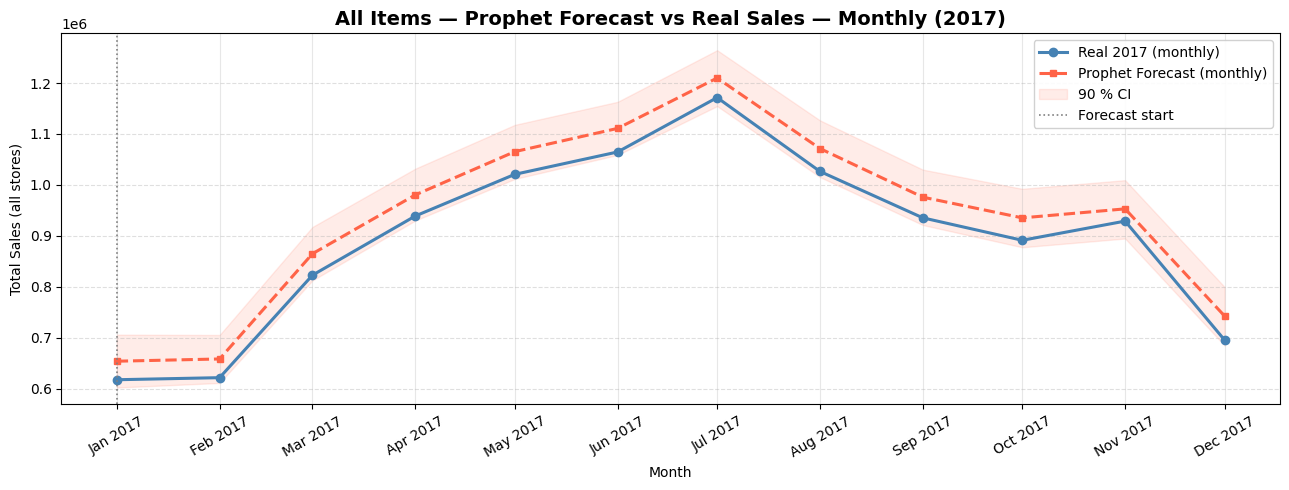

In [ ]:
from prophet import Prophet

# ── 1. Daily series for all items ────────────────────────────────────────────
all_items_daily = df_train.groupby('date')['sales'].sum()
all_items_daily.index = pd.to_datetime(all_items_daily.index)

train_daily = all_items_daily[all_items_daily.index.year < 2017]
test_daily  = all_items_daily[all_items_daily.index.year == 2017]

print(f"Train: {len(train_daily)} days  |  Test (2017): {len(test_daily)} days")

# ── 2. Format for Prophet (requires columns 'ds' and 'y') ────────────────────
train_prophet = train_daily.reset_index()
train_prophet.columns = ['ds', 'y']

# ── 3. Fit Prophet model ──────────────────────────────────────────────────────
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',  # better for retail sales
    interval_width=0.90                 # 90% CI
)
model.fit(train_prophet)

# ── 4. Forecast 2017 (365 days) ───────────────────────────────────────────────
future   = model.make_future_dataframe(periods=365, freq='D')
forecast = model.predict(future)

# Keep only 2017
forecast_2017 = (
    forecast[forecast['ds'].dt.year == 2017]
    [['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
    .set_index('ds')
)

# ── 5. Aggregate daily → monthly ──────────────────────────────────────────────
pred_mean     = forecast_2017['yhat'].resample('MS').sum()
pred_ci_lower = forecast_2017['yhat_lower'].resample('MS').sum()
pred_ci_upper = forecast_2017['yhat_upper'].resample('MS').sum()

test_ts           = test_daily.resample('MS').sum()   # real monthly 2017
all_items_monthly = all_items_daily.resample('MS').sum()  # full history monthly

# ── 6. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))


# Real 2017 monthly
ax.plot(test_ts.index, test_ts.values,
        color='steelblue', linewidth=2.2, marker='o', markersize=6,
        label='Real 2017 (monthly)')

# Prophet forecast
ax.plot(pred_mean.index, pred_mean.values,
        color='tomato', linewidth=2.2, linestyle='--', marker='s', markersize=5,
        label='Prophet Forecast (monthly)')

# CI band
ax.fill_between(pred_mean.index, pred_ci_lower, pred_ci_upper,
                color='tomato', alpha=0.12, label='90 % CI')

ax.axvline(pd.Timestamp('2017-01-01'),
           color='grey', linestyle=':', linewidth=1.2, label='Forecast start')

ax.set_title('All Items — Prophet Forecast vs Real Sales — Monthly (2017)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales (all stores)')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=30)
ax.legend(framealpha=0.9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
pred_mean5 


date
2017-01-01    4689.589882
2017-02-01    4742.549802
2017-03-01    5927.260617
2017-04-01    6615.084616
2017-05-01    7243.729861
2017-06-01    7409.366750
2017-07-01    8051.372422
2017-08-01    7209.710720
2017-09-01    6511.956675
2017-10-01    6298.780445
2017-11-01    6641.461372
2017-12-01    5067.375419
Freq: MS, dtype: float64

<Figure size 1500x600 with 0 Axes>

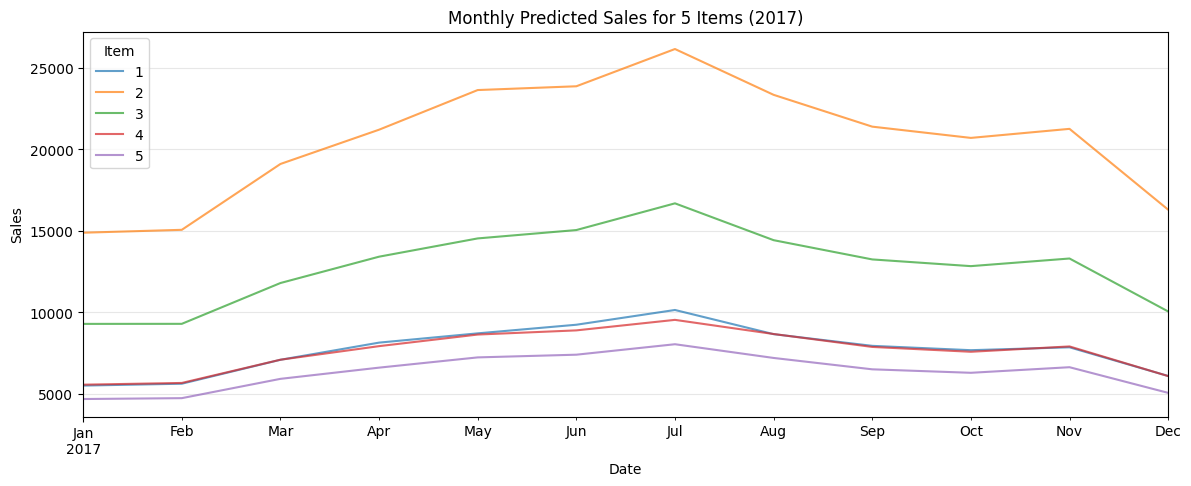

In [ ]:
# All predictions
# Combine the 5 predictions into a single DataFrame
pred_mean1.name = 1
pred_mean2.name = 2
pred_mean3.name = 3
pred_mean4.name = 4
pred_mean5.name = 5

df_test = pd.concat([pred_mean1, pred_mean2, pred_mean3, pred_mean4, pred_mean5], axis=1)
df_test.columns = [1, 2, 3, 4, 5]
df_test.index.name = 'date'
df_test = df_test.reset_index().melt(id_vars='date', var_name='item', value_name='sales')

# Plot
plt.figure(figsize=(15, 6))
df_test.groupby(['date', 'item'])['sales'].sum().unstack().iloc[:, :5].plot(
    title='Monthly Predicted Sales for 5 Items (2017)', alpha=0.7
)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend(title='Item')
plt.grid(True)
plt.show()